## Template d’Analyse Exploratoire de Données (AED)

Ce notebook sert de point de départ rapide pour les AED.

Sections incluses:
- Imports et configuration
- Chargement des données (Excel, CSV/URL)
- Description du dataset (types, échelles, % manquants)
- Nettoyage (doublons, conversions, renommage de colonnes)
- Analyse de la cible et de son équilibre
- Blocs de statistiques (globales et groupées par cible)
- Visualisations (boxplots vs cible, heatmap avec seuil ajustable)

Paramétrer la cellule « Paramètres » puis exécuter séquentiellement.


In [66]:
# Paramètres
projectName = "Predict Students' Dropout and Academic Success"
randomSeed = 42

# Options de chargement par défaut
# dataSource peut être "excel", "csv_url" ou "ucimlrepo"
dataSource = "ucimlrepo"
excelPath = "./bcw_data.xlsx"  # ajustez selon votre projet
sheetName = 0

csvUrl = ""  # ex: "https://example.com/data.csv"

# Paramètres UCI ML Repository
ucimlrepoId = 697  # ID du dataset "Predict Students' Dropout and Academic Success"

# Cible et colonnes utiles
# targetColumn sera utilisée pour l'équilibre des classes et les groupby
targetColumn = "Target"  # colonne cible du dataset UCI

# Colonnes numériques/catégorielles (laisser None pour détection auto)
numericColumns = None
categoricalColumns = None

# Paramètres d'affichage
maxRowsToShow = 10
floatPrecision = 10

# Paramètres de visualisation
heatmapCorrThreshold = 0.95  # seuil minimal de corrélation à afficher
figSize = (10, 6)


In [67]:
# Création du requirements.txt (à exécuter avant les imports)
from pathlib import Path

# Liste simple des packages requis pour ce notebook (modifiez selon besoin)
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scipy",
    "openpyxl",      # lecture Excel
    "scikit-learn",  # ML éventuel
    "SQLAlchemy",    # chargement SQL optionnel
    "ucimlrepo",     # chargement datasets UCI ML Repository
    "prince",        # Analyse des Correspondances Multiples (MCA)
]

# Tri + déduplication (sans versions)
requirements = sorted(set(packages), key=lambda x: x.lower())

outPath = Path("requirements.txt")
outPath.write_text("\n".join(requirements), encoding="utf-8")
print(f"requirements.txt écrit: {outPath.resolve()}")
print("Installez ensuite avec: pip install -r requirements.txt")
print("Contenu:\n" + "\n".join(requirements))


requirements.txt écrit: C:\Users\emile\Desktop\Projet Plateforme\ANN\requirements.txt
Installez ensuite avec: pip install -r requirements.txt
Contenu:
matplotlib
numpy
openpyxl
pandas
prince
scikit-learn
scipy
seaborn
SQLAlchemy
ucimlrepo


In [68]:
# Imports et configuration globale
import os
import sys
import math
import warnings
from typing import Optional, List, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Affichage
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", floatPrecision)

np.random.seed(randomSeed)
warnings.filterwarnings("ignore")

print(f"Projet: {projectName} - seed={randomSeed}")
print(f"Version pandas: {pd.__version__}, numpy: {np.__version__}")


Projet: Predict Students' Dropout and Academic Success - seed=42
Version pandas: 2.3.3, numpy: 2.3.5


In [69]:
# Chargement des données — fonctions utilitaires
from urllib.parse import urlparse

try:
    from sqlalchemy import create_engine
except Exception:
    create_engine = None

try:
    from ucimlrepo import fetch_ucirepo
except Exception:
    fetch_ucirepo = None


def loadFromExcel(path: str, sheet: int | str = 0) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return pd.read_excel(path, sheet_name=sheet)


def loadFromCsvUrl(url: str) -> pd.DataFrame:
    parsed = urlparse(url)
    if not parsed.scheme:
        # Peut être un chemin local CSV
        if not os.path.exists(url):
            raise FileNotFoundError(f"Ni URL ni fichier CSV local valide: {url}")
        return pd.read_csv(url)
    return pd.read_csv(url)


def loadFromSql(connString: str, query: str) -> pd.DataFrame:
    if create_engine is None:
        raise ImportError("SQLAlchemy n'est pas installé. Ajoutez-le si vous utilisez SQL.")
    if not connString:
        raise ValueError("sqlConnString est vide.")
    engine = create_engine(connString)
    with engine.connect() as conn:
        return pd.read_sql_query(query, conn)


def loadFromUciMlRepo(datasetId: int) -> pd.DataFrame:
    if fetch_ucirepo is None:
        raise ImportError("ucimlrepo n'est pas installé. Installez-le avec: pip install ucimlrepo")
    print(f"Chargement du dataset UCI ML Repository ID: {datasetId}")
    dataset = fetch_ucirepo(id=datasetId)
    # Combiner features et targets en un seul DataFrame
    X = dataset.data.features
    y = dataset.data.targets
    # Fusionner les features et la cible
    df = pd.concat([X, y], axis=1)
    print(f"Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
    return df


def unifiedLoad(dataSource: str) -> pd.DataFrame:
    source = dataSource.lower().strip()
    if source == "excel":
        return loadFromExcel(excelPath, sheetName)
    if source == "csv_url":
        if not csvUrl:
            raise ValueError("csvUrl est vide.")
        return loadFromCsvUrl(csvUrl)
    if source == "ucimlrepo":
        return loadFromUciMlRepo(ucimlrepoId)
    raise ValueError(f"Source de données non reconnue: {dataSource}. Utilisez 'excel', 'csv_url' ou 'ucimlrepo'.")


In [70]:
# Chargement effectif des données
try:
    df = unifiedLoad(dataSource)
    print(f"Données chargées: {df.shape[0]} lignes, {df.shape[1]} colonnes")
    display(df.head(maxRowsToShow))
except Exception as e:
    print("Erreur lors du chargement:", e)
    df = pd.DataFrame()


Chargement du dataset UCI ML Repository ID: 697
Dataset chargé: 4424 lignes, 37 colonnes
Données chargées: 4424 lignes, 37 colonnes


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.00000000,0,0,0,0,0,0.00000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.00000000,0,0,6,6,6,13.66666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.00000000,0,0,6,0,0,0.00000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.42857143,0,0,6,10,5,12.40000000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.33333333,0,0,6,6,6,13.00000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,9,7,114.8,0,0,1,1,1,0,50,0,0,5,10,5,11.85714286,0,0,5,17,5,11.50000000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,7,10,128.4,1,0,0,1,0,1,18,0,0,7,9,7,13.30000000,0,0,8,8,8,14.34500000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,9,9,113.1,1,0,0,0,1,0,22,0,0,5,5,0,0.00000000,0,0,5,5,0,0.00000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,9,9,129.3,0,0,0,1,0,1,21,1,0,6,8,6,13.87500000,0,0,6,7,6,14.14285714,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,4,7,123.0,1,0,1,0,0,0,18,0,0,6,9,5,11.40000000,0,0,6,14,2,13.50000000,0,8.9,1.4,3.51,Dropout


In [71]:
# Description du dataset
assert isinstance(df, pd.DataFrame), "df doit être un DataFrame"

def detectColumnTypes(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    if numericColumns is not None and categoricalColumns is not None:
        return list(numericColumns), list(categoricalColumns)
    inferredNumeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    inferredCategorical = [c for c in df.columns if c not in inferredNumeric]
    return inferredNumeric, inferredCategorical

numCols, catCols = detectColumnTypes(df)
print("Colonnes numériques:", numCols)
print("Colonnes catégorielles:", catCols)

# % de données manquantes (NaN uniquement)
"""missingPct = df.isna().mean().sort_values(ascending=False) * 100
print("% de données manquantes par colonne:")
display(missingPct.to_frame(name="missing_%").T if missingPct.empty else missingPct)"""

# % de données manquantes en traitant 0 comme manquant pour les colonnes numériques
if len(numCols) > 0:
    missingOrZero = df.isna().copy()
    try:
        missingOrZero[numCols] = missingOrZero[numCols] | (df[numCols] == 0)
    except Exception:
        numMask = df[numCols].apply(pd.to_numeric, errors="coerce") == 0
        missingOrZero[numCols] = missingOrZero[numCols] | numMask
    missingOrZeroPct = missingOrZero.mean().sort_values(ascending=False) * 100
    print("% de données manquantes OU égales à 0 (numériques: 0 considéré manquant):")
    display(missingOrZeroPct.to_frame(name="missing_or_zero_%").T if missingOrZeroPct.empty else missingOrZeroPct)

# Doublons (toutes colonnes)
duplicateCount = int(df.duplicated().sum())
duplicatePct = (duplicateCount / len(df) * 100) if len(df) > 0 else 0
print(f"Lignes dupliquées (toutes colonnes): {duplicateCount} ({duplicatePct:.2f}%)")
if duplicateCount > 0:
    print("Exemples de lignes dupliquées:")
    display(df[df.duplicated(keep=False)].head(maxRowsToShow))

# Aperçu dtypes
display(df.dtypes.to_frame(name="dtype"))


Colonnes numériques: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
Co

Educational special needs                         98.8471971067
International                                     97.5135623870
Curricular units 2nd sem (without evaluations)    93.6256781193
Curricular units 1st sem (without evaluations)    93.3544303797
Debtor                                            88.6301989150
Curricular units 2nd sem (credited)               88.0198915009
Curricular units 1st sem (credited)               86.9575045208
Scholarship holder                                75.1582278481
Gender                                            64.8282097649
Displaced                                         45.1627486438
Curricular units 2nd sem (grade)                  19.6654611212
Curricular units 2nd sem (approved)               19.6654611212
Curricular units 1st sem (approved)               16.2296564195
Curricular units 1st sem (grade)                  16.2296564195
Tuition fees up to date                           11.9349005425
Daytime/evening attendance              

Lignes dupliquées (toutes colonnes): 0 (0.00%)


,dtype
Marital Status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


In [72]:
# Outils de nettoyage: doublons, conversions, renommages
from typing import Dict


def dropDuplicates(data: pd.DataFrame, subset: Optional[list[str]] = None, keep: str = "first") -> pd.DataFrame:
    before = len(data)
    out = data.drop_duplicates(subset=subset, keep=keep)
    print(f"Doublons supprimés: {before - len(out)}")
    return out


def convertColumns(data: pd.DataFrame, conversions: Dict[str, str | type]) -> pd.DataFrame:
    out = data.copy()
    for col, dtype in conversions.items():
        if col not in out.columns:
            print(f"Colonne absente, ignorée: {col}")
            continue
        try:
            if dtype == "category":
                out[col] = out[col].astype("category")
            elif dtype == "datetime":
                out[col] = pd.to_datetime(out[col], errors="coerce")
            else:
                out[col] = out[col].astype(dtype)
            print(f"Converti {col} -> {dtype}")
        except Exception as e:
            print(f"Échec conversion {col} -> {dtype}: {e}")
    return out


def renameColumns(data: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    missing = [c for c in mapping.keys() if c not in data.columns]
    if missing:
        print("Attention, colonnes à renommer introuvables:", missing)
    return data.rename(columns=mapping)

# Exemples d'utilisation (décommenter et adapter):
# df = dropDuplicates(df)
# df = convertColumns(df, {"date_col": "datetime", "code": "category", "age": "float64"})
# df = renameColumns(df, {"oldName": "newName"})


In [73]:
# Analyse de la cible et de son équilibre
from collections import Counter

if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour activer l'analyse de la cible.")
else:
    targetSeries = df[targetColumn]
    print("Aperçu de la cible:")
    display(targetSeries.value_counts(dropna=False).to_frame(name="count"))
    vc = targetSeries.value_counts(normalize=True, dropna=False) * 100
    print("Répartition (%) de la cible:")
    display(vc.to_frame(name="percentage"))

    # Mesure simple d'équilibre: ratio minoritaire/majoritaire (hors NaN)
    vcNoNa = targetSeries.dropna().value_counts()
    if len(vcNoNa) >= 2:
        minority = vcNoNa.min()
        majority = vcNoNa.max()
        balanceRatio = minority / majority
        print(f"Balance ratio (minority/majority): {balanceRatio:.3f}")
    else:
        print("La cible n'a pas au moins 2 classes non nulles.")


Aperçu de la cible:


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


Répartition (%) de la cible:


,percentage
Target,
Graduate,49.9321880651
Dropout,32.1202531646
Enrolled,17.9475587703


Balance ratio (minority/majority): 0.359


In [74]:
# Statistiques descriptives

statsFunctions = [
    ("mean", np.mean),
    ("median", np.median),
    ("min", np.min),
    ("q1", lambda x: np.nanpercentile(x, 25)),
    ("q3", lambda x: np.nanpercentile(x, 75)),
    ("max", np.max),
    ("var", np.var),
    ("std", np.std),
    ("iqr", lambda x: np.nanpercentile(x, 75) - np.nanpercentile(x, 25)),
    ("range", lambda x: np.nanmax(x) - np.nanmin(x)),
]

if len(numCols) == 0:
    print("Aucune colonne numérique détectée.")
else:
    print("Statistiques globales:")
    globalStats = pd.concat({name: df[numCols].apply(func) for name, func in statsFunctions}, axis=1).T
    display(globalStats)

    if targetColumn is not None and targetColumn in df.columns:
        print("Statistiques groupées par cible:")
        groupedStats = pd.concat({name: df.groupby(targetColumn)[numCols].aggregate(func) for name, func in statsFunctions}, axis=0)
        display(groupedStats)
    else:
        print("Définissez targetColumn pour obtenir les stats groupées.")


Statistiques globales:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
mean,1.1785714286,18.6690777577,1.7278481013,8.8566426311e+03,0.8908227848,4.5777576854,132.6133137432,1.8731916817,19.5619349005,22.2753164557,10.9608951175,11.0323236890,126.9781193490,0.5483725136,0.0115280289,0.1136980108,0.8806509946,0.3517179024,0.2484177215,23.2651446655,0.0248643761,0.7099909584,6.2705696203,8.2990506329,4.7066003617,10.6408215752,0.1376582278,0.5418173599,6.2321428571,8.0632911392,4.4358047016,10.2302057227,0.1503164557,11.5661392405,1.2280289331,0.0019688065
median,1.0000000000,17.0000000000,1.0000000000,9.2380000000e+03,1.0000000000,1.0000000000,133.1000000000,1.0000000000,19.0000000000,19.0000000000,5.0000000000,7.0000000000,126.1000000000,1.0000000000,0.0000000000,0.0000000000,1.0000000000,0.0000000000,0.0000000000,20.0000000000,0.0000000000,0.0000000000,6.0000000000,8.0000000000,5.0000000000,12.2857142900,0.0000000000,0.0000000000,6.0000000000,8.0000000000,5.0000000000,12.2000000000,0.0000000000,11.1000000000,1.4000000000,0.3200000000
min,1.0000000000,1.0000000000,0.0000000000,3.3000000000e+01,0.0000000000,1.0000000000,95.0000000000,1.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,95.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,17.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,7.6000000000,-0.8000000000,-4.0600000000
q1,1.0000000000,1.0000000000,1.0000000000,9.0850000000e+03,1.0000000000,1.0000000000,125.0000000000,1.0000000000,2.0000000000,3.0000000000,4.0000000000,4.0000000000,117.9000000000,0.0000000000,0.0000000000,0.0000000000,1.0000000000,0.0000000000,0.0000000000,19.0000000000,0.0000000000,0.0000000000,5.0000000000,6.0000000000,3.0000000000,11.0000000000,0.0000000000,0.0000000000,5.0000000000,6.0000000000,2.0000000000,10.7500000000,0.0000000000,9.4000000000,0.3000000000,-1.7000000000
q3,1.0000000000,39.0000000000,2.0000000000,9.5560000000e+03,1.0000000000,1.0000000000,140.0000000000,1.0000000000,37.0000000000,37.0000000000,9.0000000000,9.0000000000,134.8000000000,1.0000000000,0.0000000000,0.0000000000,1.0000000000,1.0000000000,0.0000000000,25.0000000000,0.0000000000,0.0000000000,7.0000000000,10.0000000000,6.0000000000,13.4000000000,0.0000000000,0.0000000000,7.0000000000,10.0000000000,6.0000000000,13.3333333300,0.0000000000,13.9000000000,2.6000000000,1.7900000000
max,6.0000000000,57.0000000000,9.0000000000,9.9910000000e+03,1.0000000000,43.0000000000,190.0000000000,109.0000000000,44.0000000000,44.0000000000,194.0000000000,195.0000000000,190.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,1.0000000000,70.0000000000,1.0000000000,20.0000000000,26.0000000000,45.0000000000,26.0000000000,18.8750000000,12.0000000000,19.0000000000,23.0000000000,33.0000000000,20.0000000000,18.5714285700,12.0000000000,16.2000000000,3.7000000000,3.5100000000
var,0.3668464221,305.6450112652,1.7256620963,4.2573438074e+06,0.0972575509,104.3551653156,173.8927770842,47.7996972273,243.4043919162,235.3577451530,697.7663279510,638.0769389043,209.6809407669,0

Statistiques groupées par cible:


Marital Status  Application mode  Application order            Course  Daytime/evening attendance  Previous qualification  Previous qualification (grade)     Nacionality  \
       Target                                                                                                                                                                                
mean   Dropout     1.2610837438     23.7128782548       1.5932441942  8.7556298381e+03                0.8543279381            5.3110485574                  131.1140745954    1.9570724842   
       Enrolled    1.1523929471     19.7997481108       1.6259445844  8.8688110831e+03                0.9055415617            4.7858942065                  131.2084382872    2.0793450882   
       Graduate    1.1349026709     15.0181077411       1.8510638298  8.9172480761e+03                0.9090086012            4.0312358533                  134.0827071073    1.7451335446   
median Dropout     1.0000000000     18.0000000000       1.0000000000  9.2380000000e+03                1.0000000000            1.0000000000                  133.1000000000    1.0000000000   
       Enrolled    1.0000000000     17.0000000000       1.0000000000  9.1470000000e+03                1.0000000000            1.0000000000                  130.0000000000    1.0000000000   
       Graduate    1.0000000000      7.0000000000       1.0000000000  9.2540000000e+03                1.0000000000            1.0000000000                  133.1000000000    1.0000000000   
min    Dropout     1.0000000000      1.0000000000       1.0000000000  3.3000000000e+01                0.0000000000            1.0000000000                   95.0000000000    1.0000000000   
       Enrolled    1.0000000000      1.0000000000       1.0000000000  3.3000000000e+01                0.0000000000            1.0000000000                   96.0000000000    1.0000000000   
       Graduate    1.0000000000      1.0000000000       0.0000000000  3.3000000000e+01                0.0000000000            1.0000000000                   97.0000000000    1.0000000000   
q1     Dropout     1.0000000000      7.0000000000       1.0000000000  9.0850000000e+03                1.0000000000            1.0000000000                  122.0000000000    1.0000000000   
       Enrolled    1.0000000000      1.0000000000       1.0000000000  9.0850000000e+03                1.0000000000            1.0000000000                  123.0000000000    1.0000000000   
       Graduate    1.0000000000      1.0000000000       1.0000000000  9.0850000000e+03                1.0000000000            1.0000000000                  126.0000000000    1.0000000000   
q3     Dropout     1.0000000000     39.0000000000       2.0000000000  9.6700000000e+03                1.0000000000            1.0000000000                  137.0000000000    1.0000000000   
       Enrolled    1.0000000000     39.0000000000       2.0000000000  9.5560000000e+03                1.0000000000            1.0000000000                  139.0000000000    1.0000000000   
       Graduate    1.0000000000     18.0000000000       2.0000000000  9.5000000000e+03                1.0000000000            1.0000000000                  141.0000000000    1.0000000000   
max    Dropout     6.0000000000     53.0000000000       6.0000000000  9.9910000000e+03                1.0000000000           43.0000000000                  190.0000000000  109.0000000000   
       Enrolled    6.0000000000     53.0000000000       9.0000000000  9.9910000000e+03                1.0000000000           42.0000000000                  190.0000000000  108.0000000000   
       Graduate    6.0000000000     57.0000000000       6.0000000000  9.9910000000e+03                1.0000000000           43.0000000000                  184.4000000000  103.0000000000   
var    Dropout     0.5212238951    294.1428551605       1.4780951720  5.1928359065e+06                0.1245393544          106.2947299561                  165.7232383860   61.4495643814   
       Enrolled    0.326053

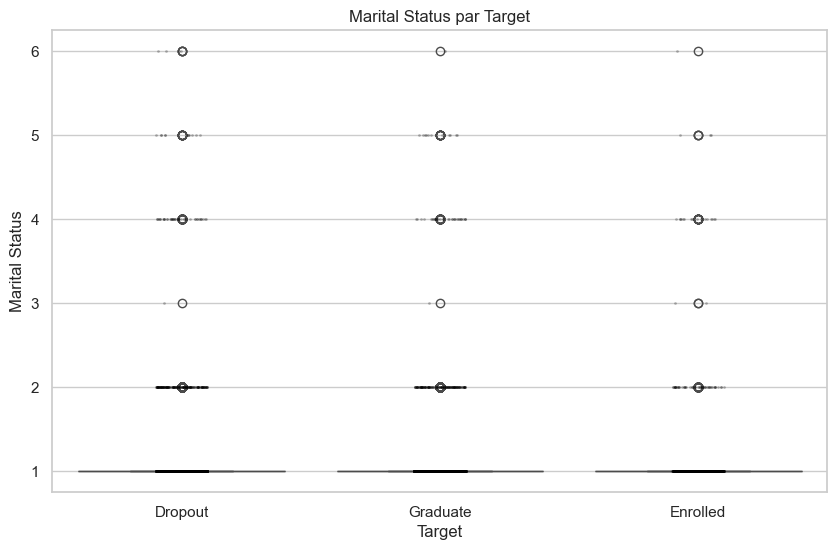

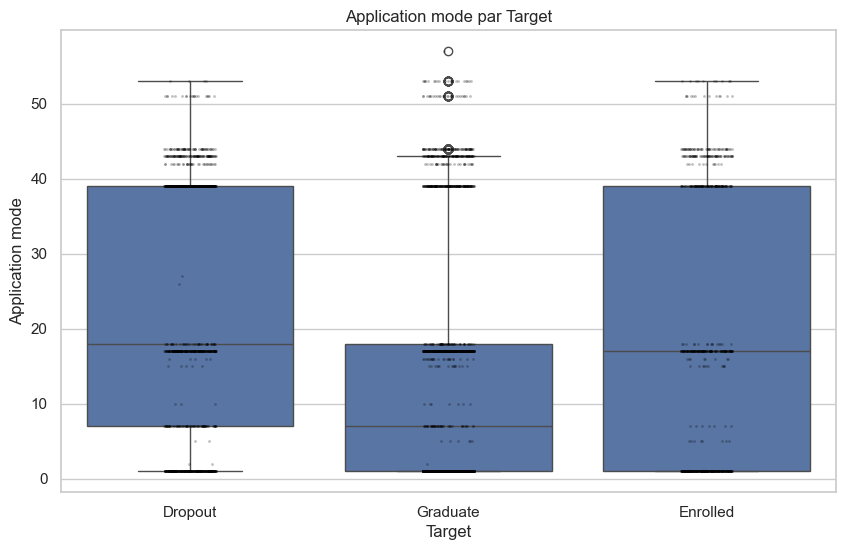

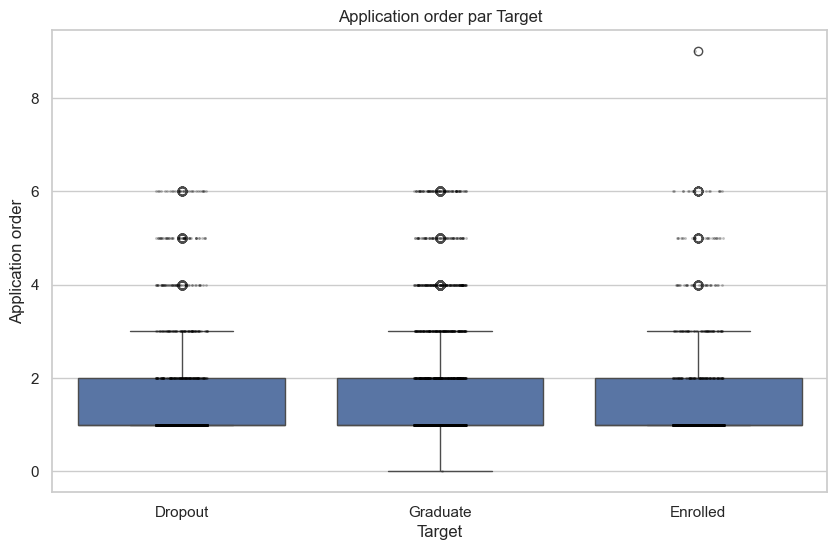

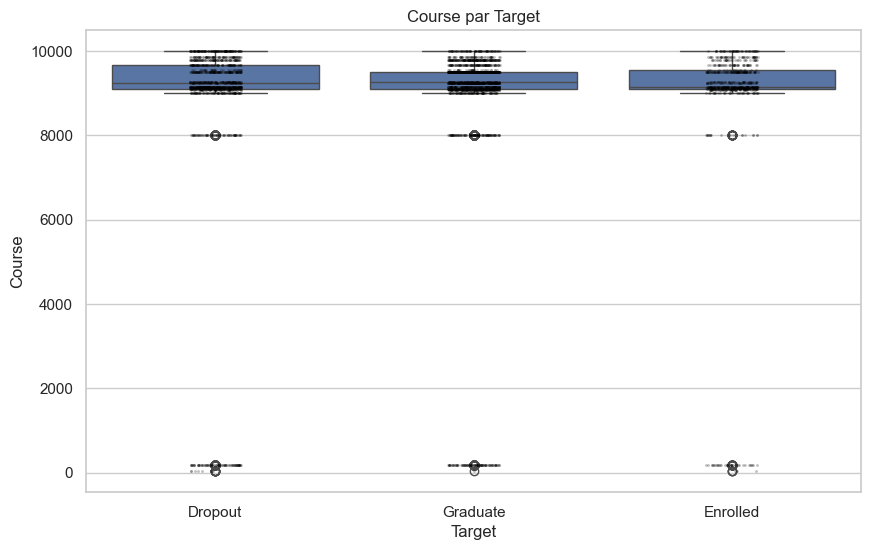

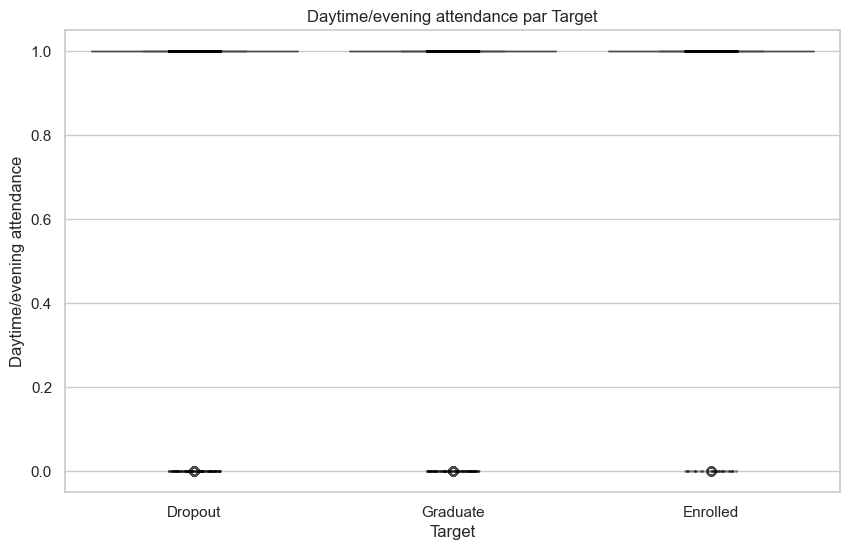

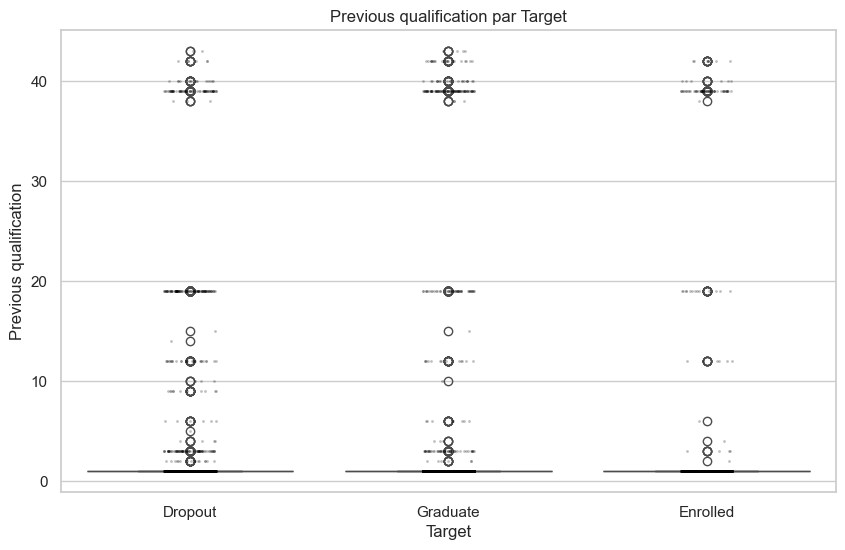

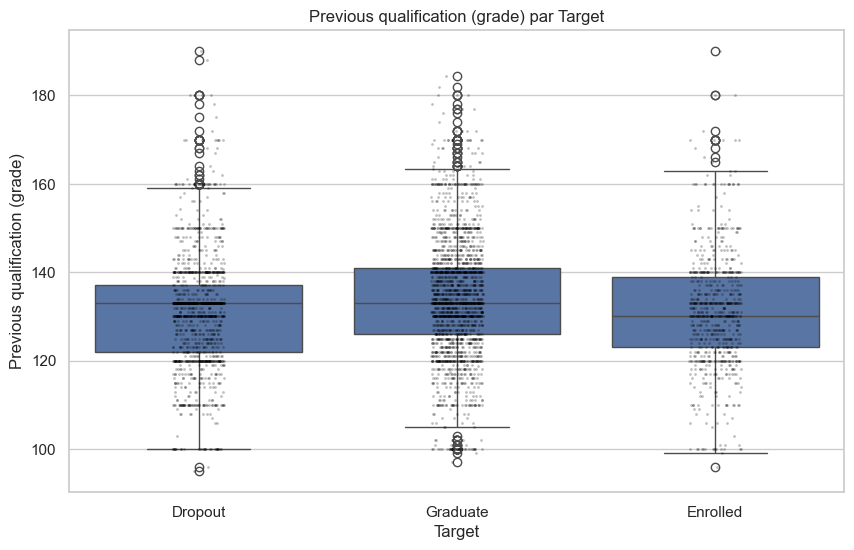

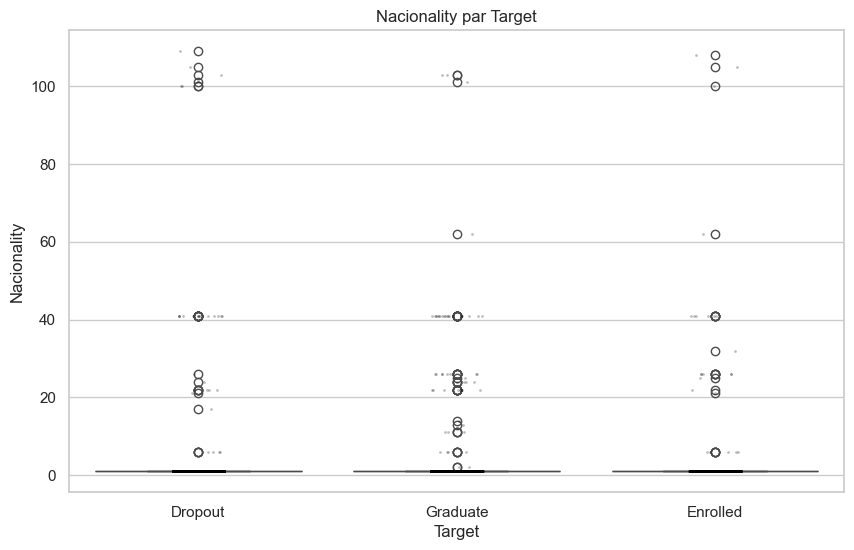

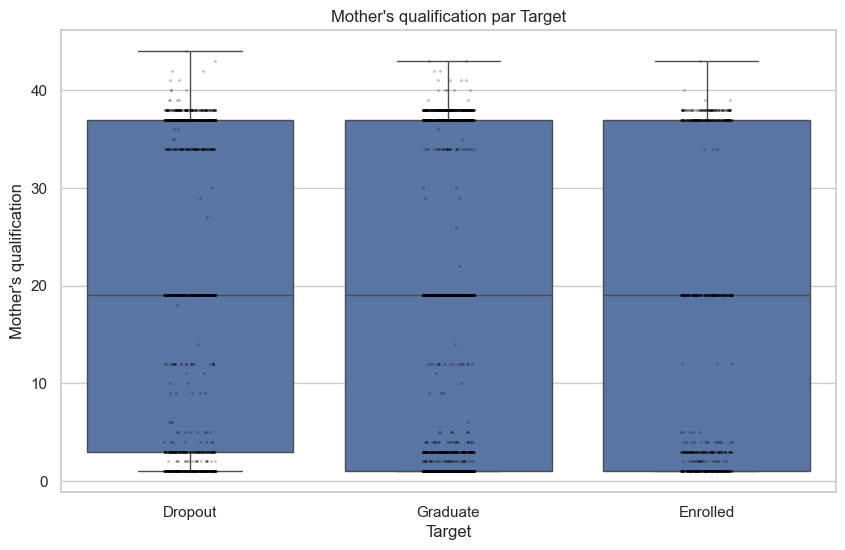

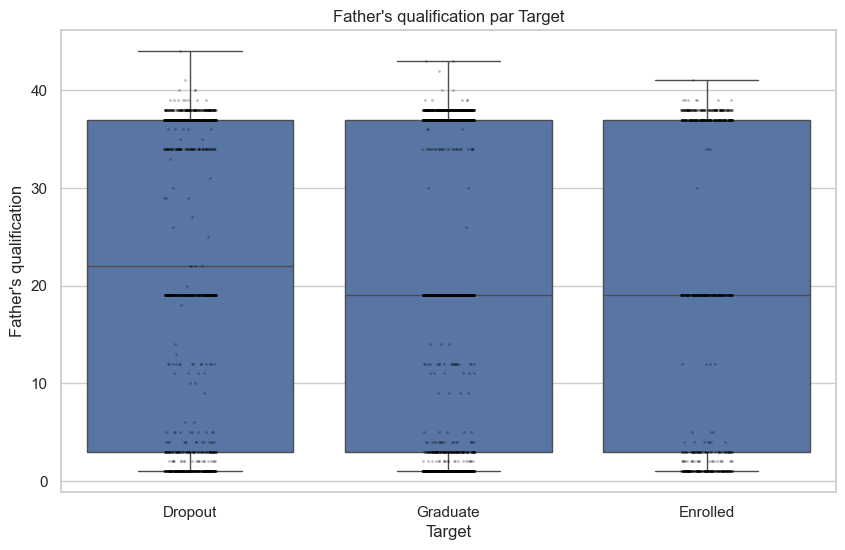

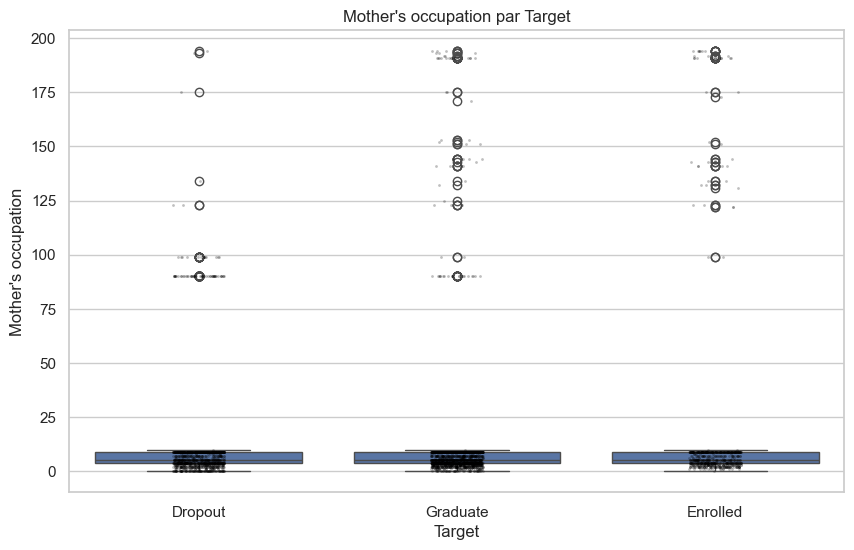

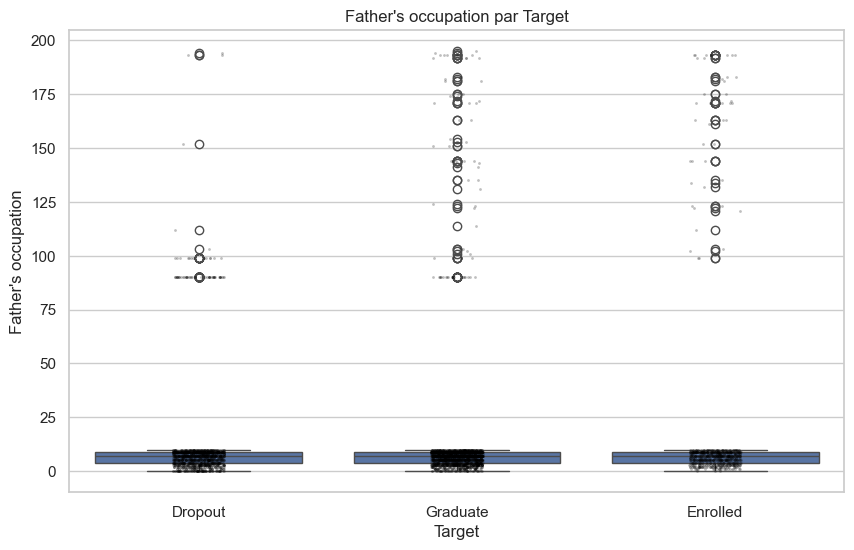

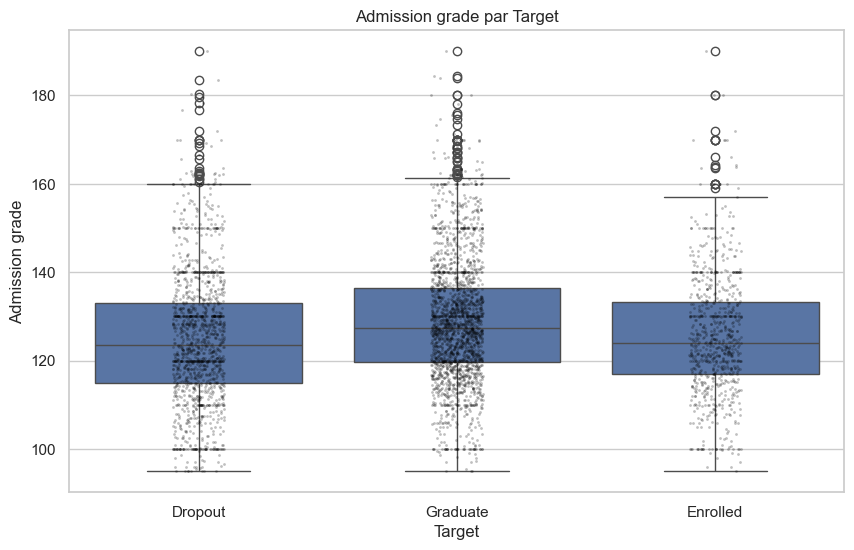

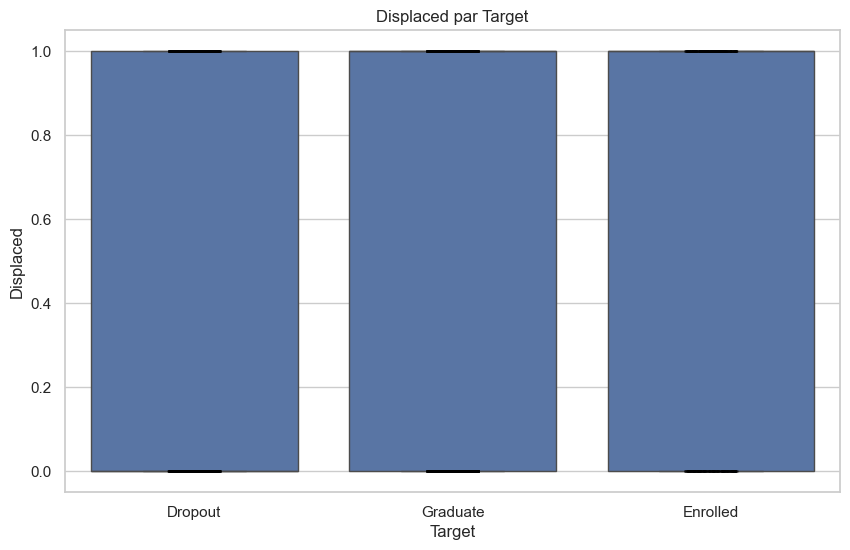

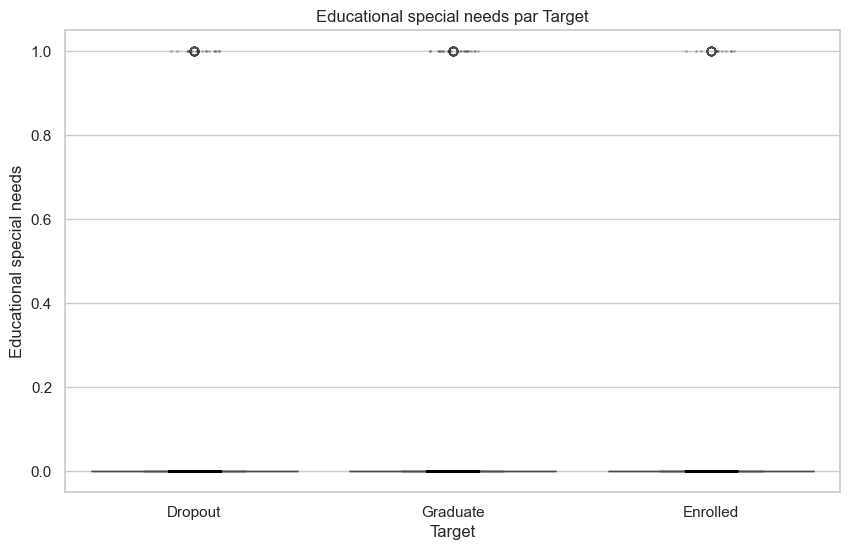

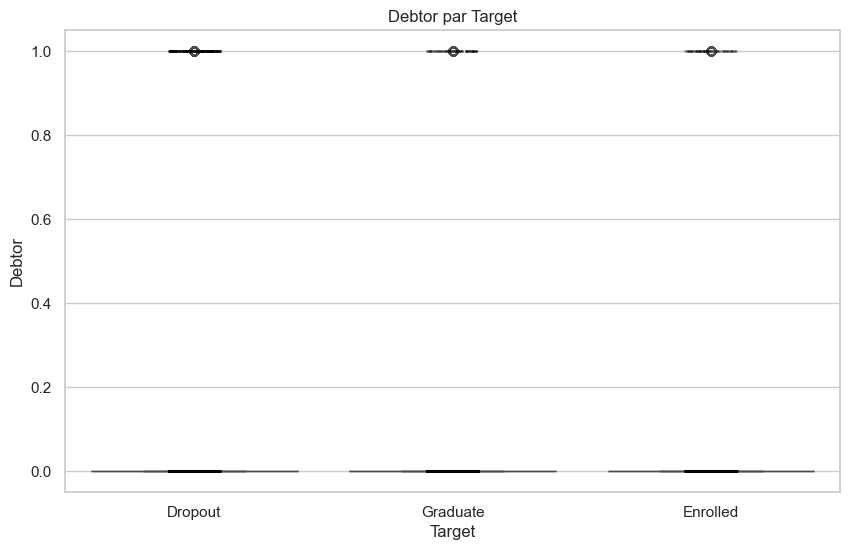

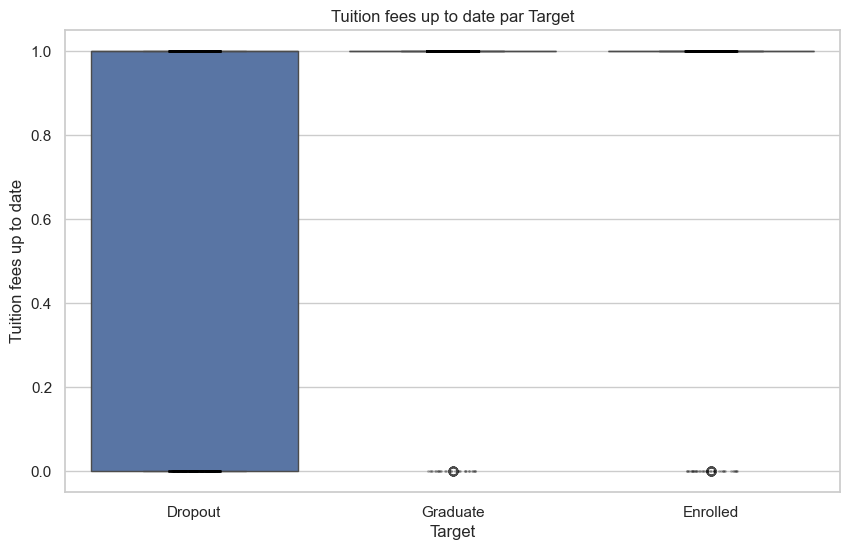

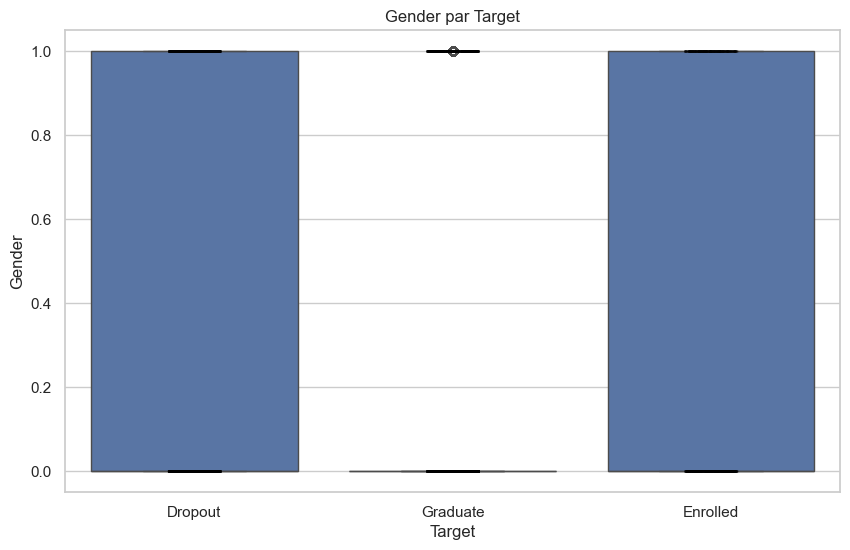

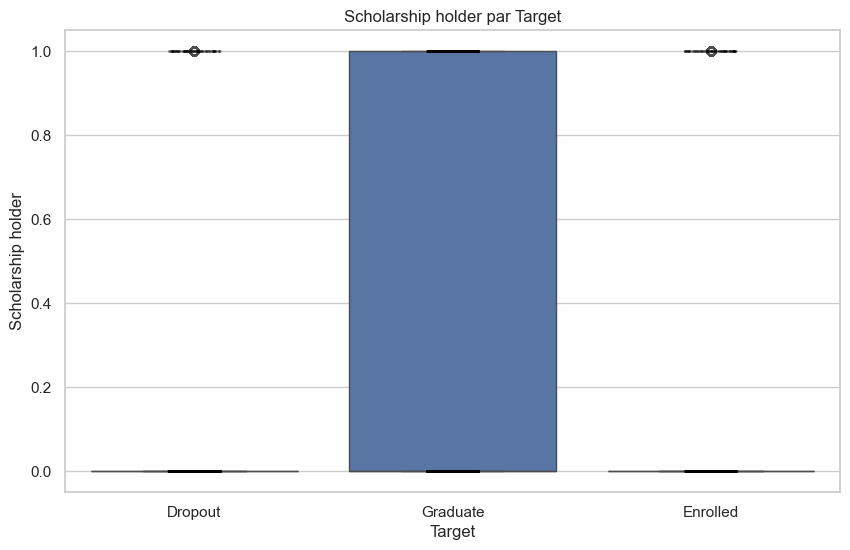

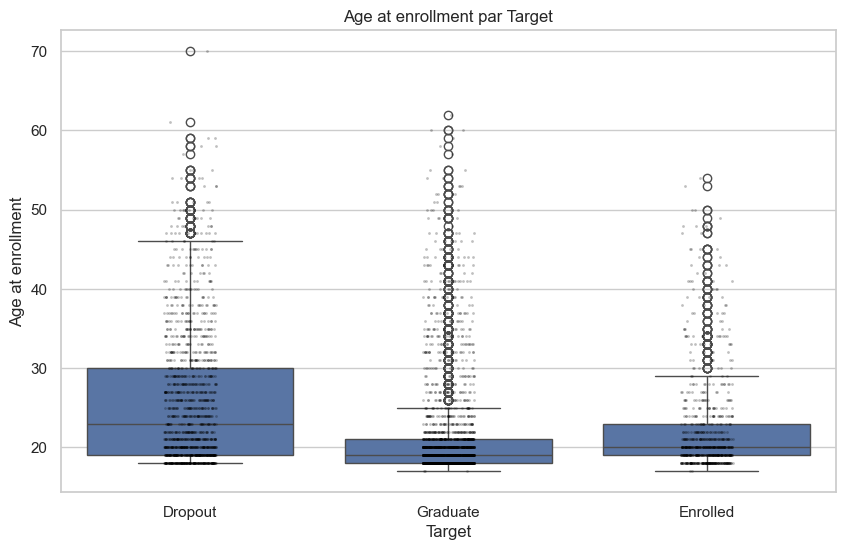

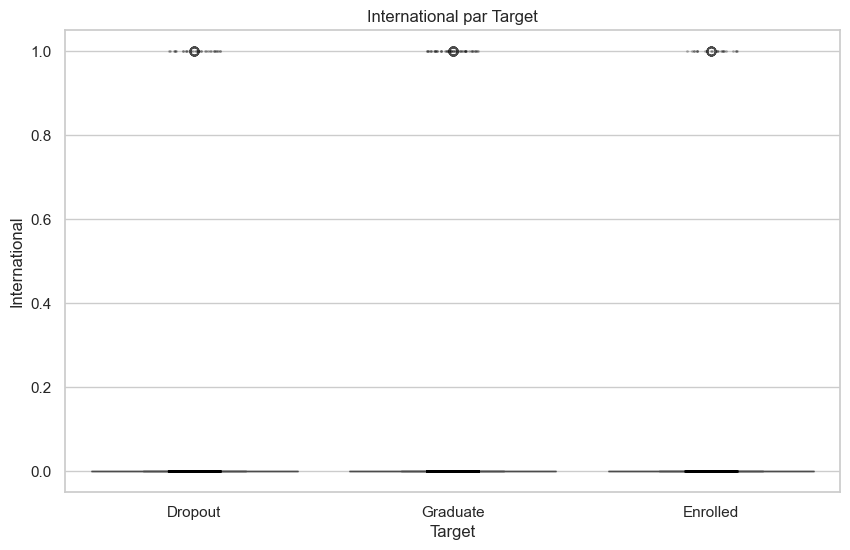

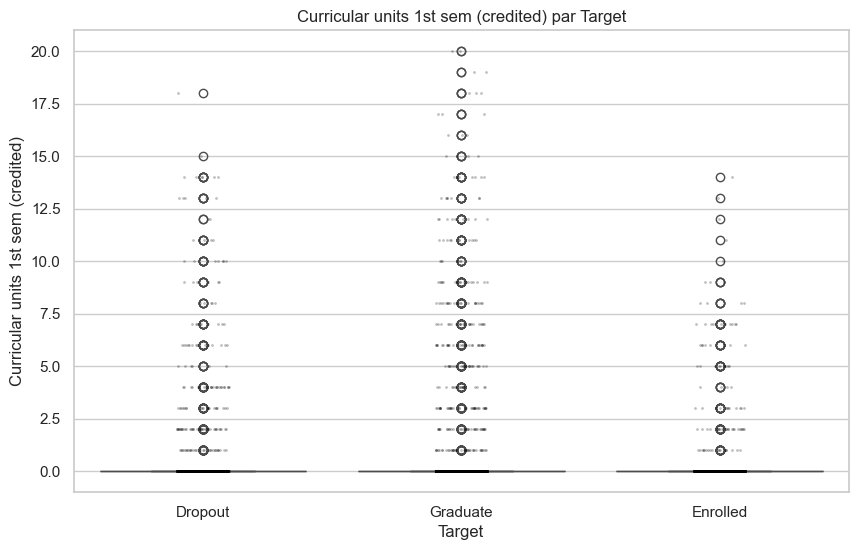

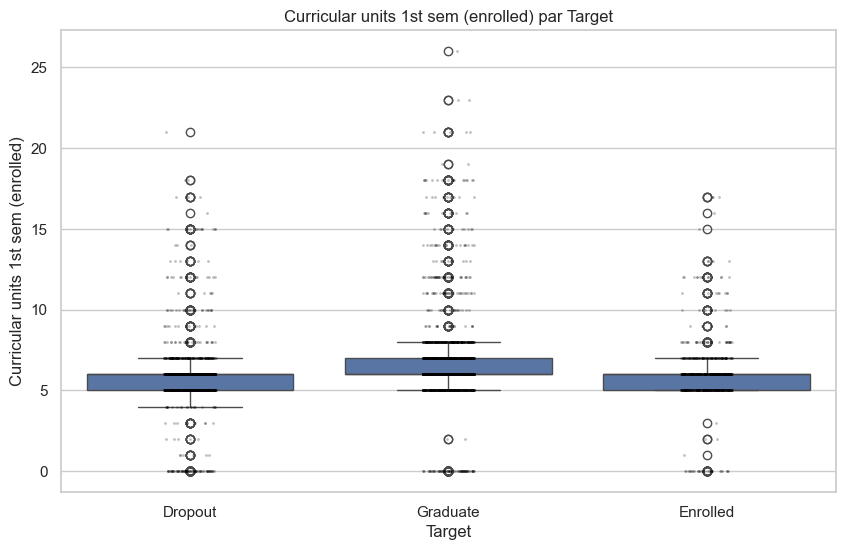

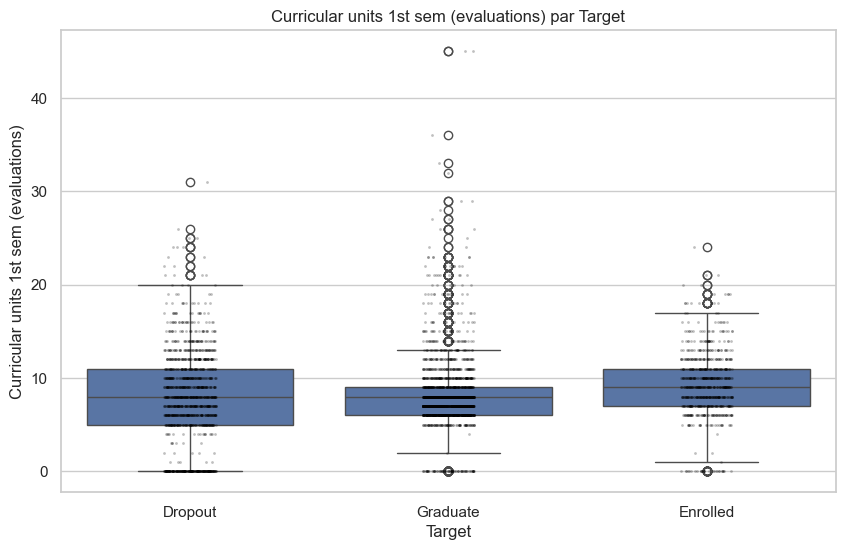

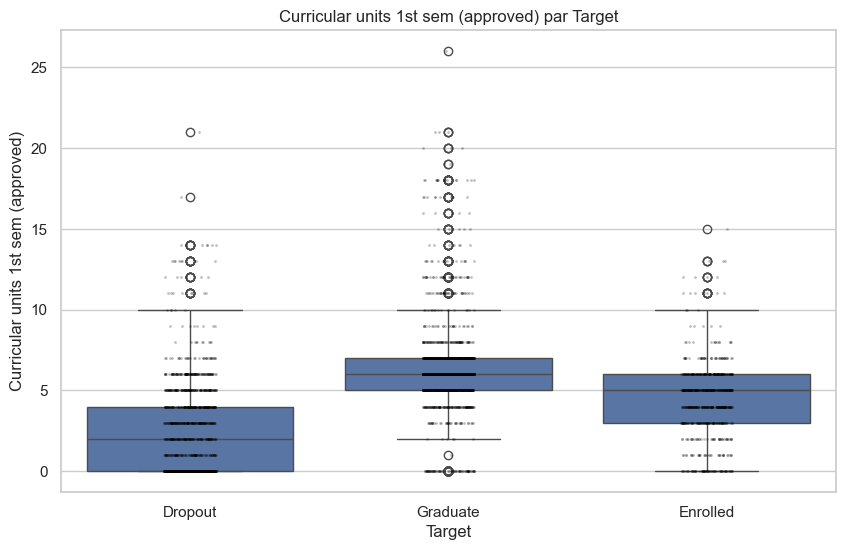

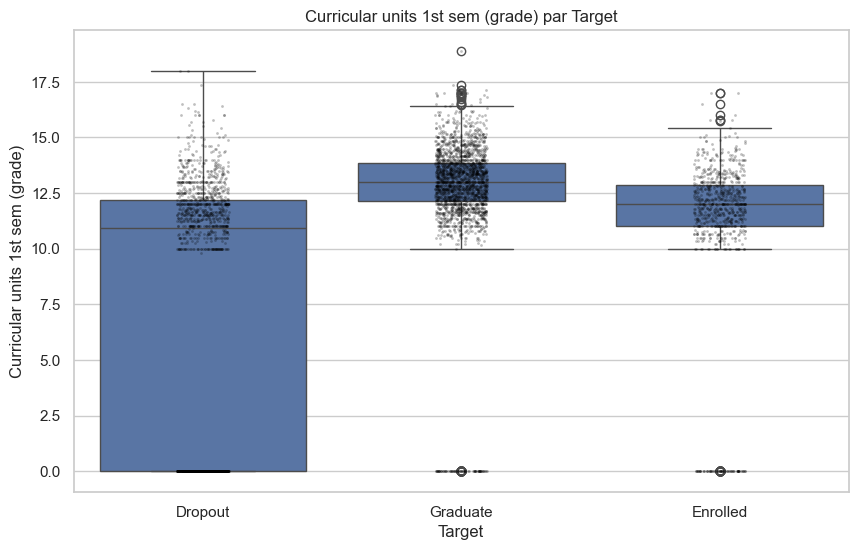

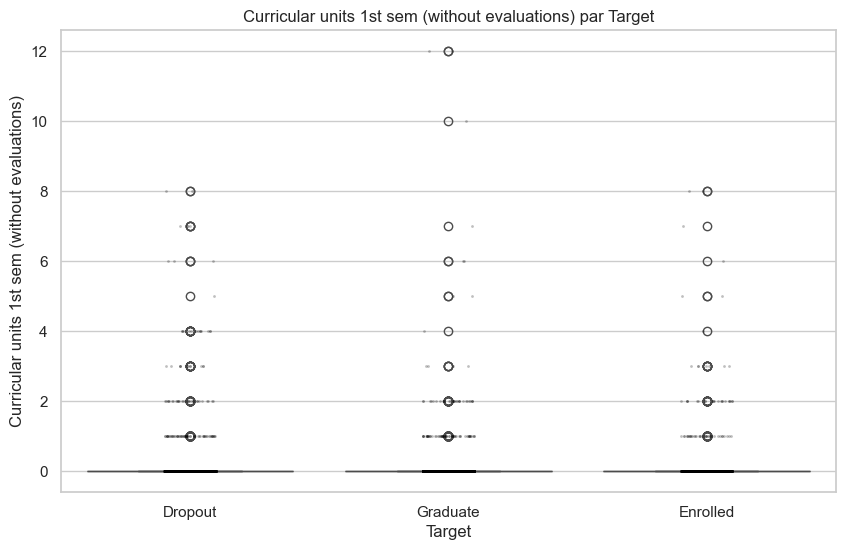

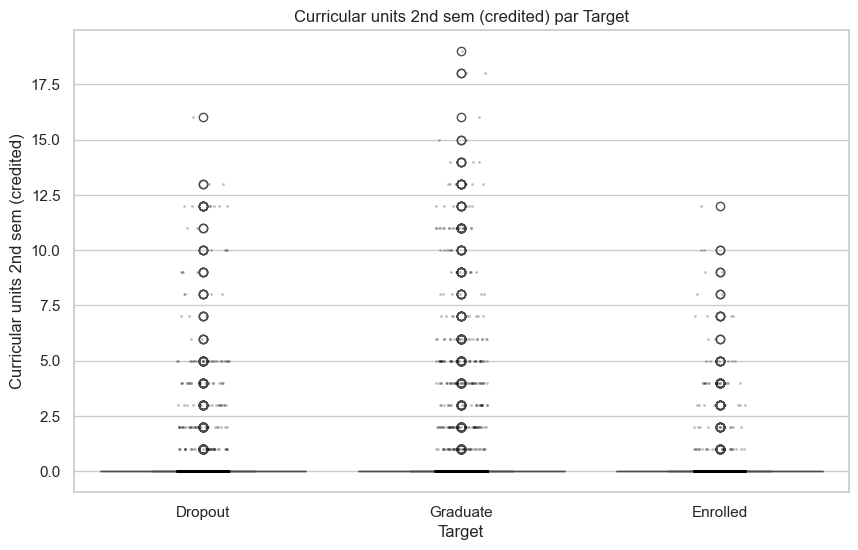

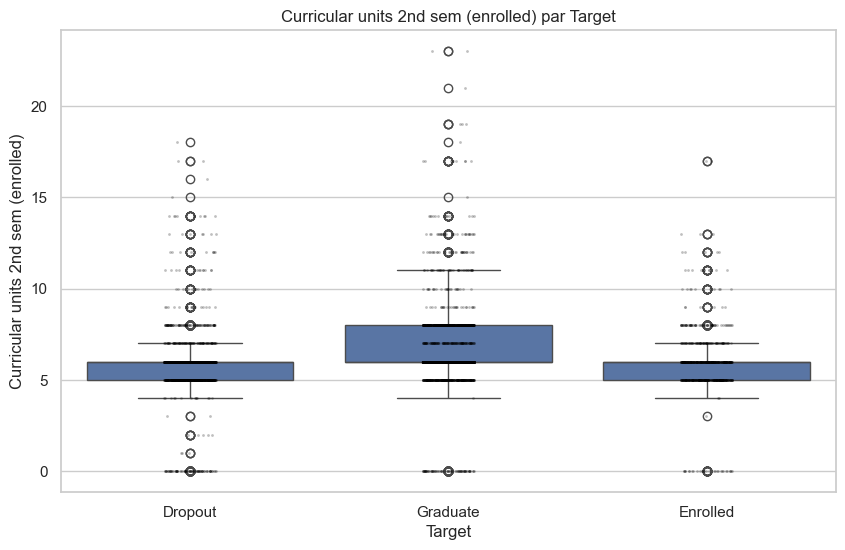

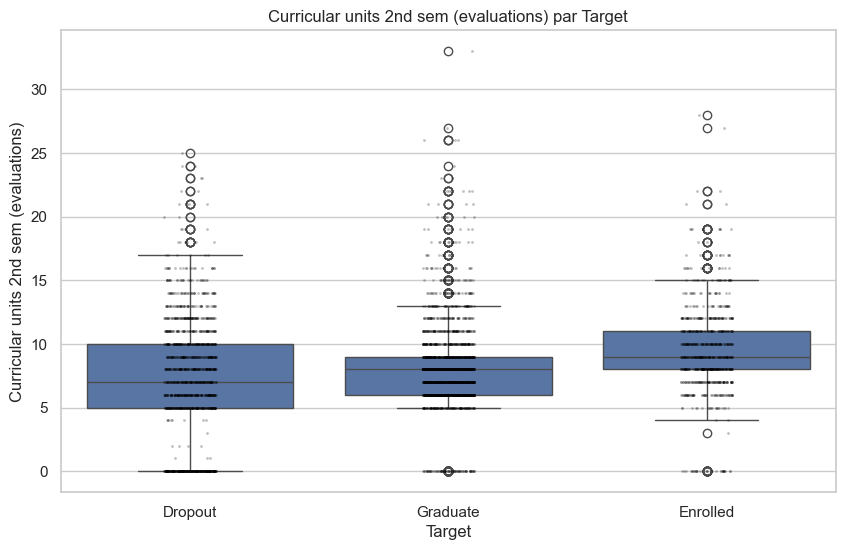

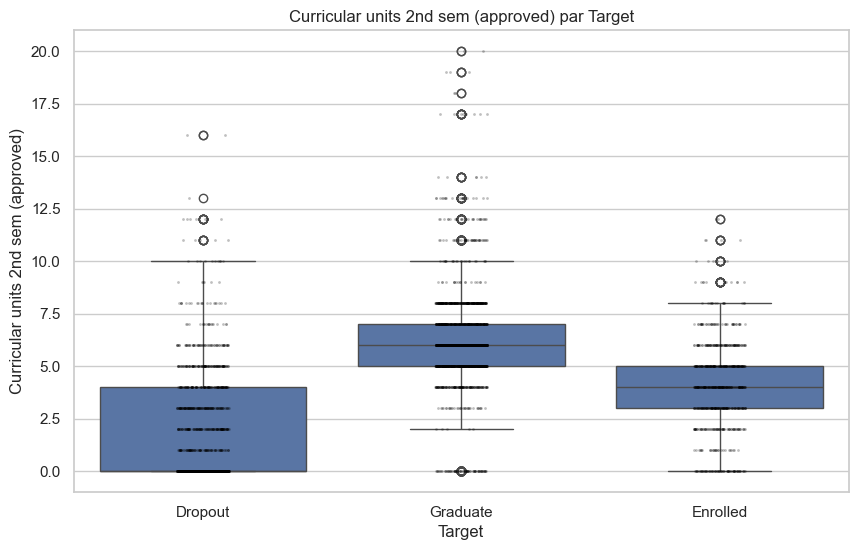

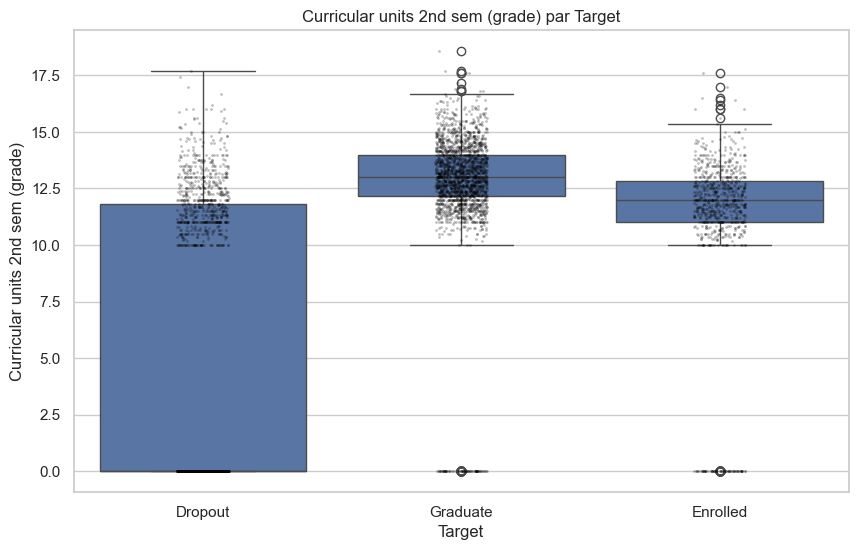

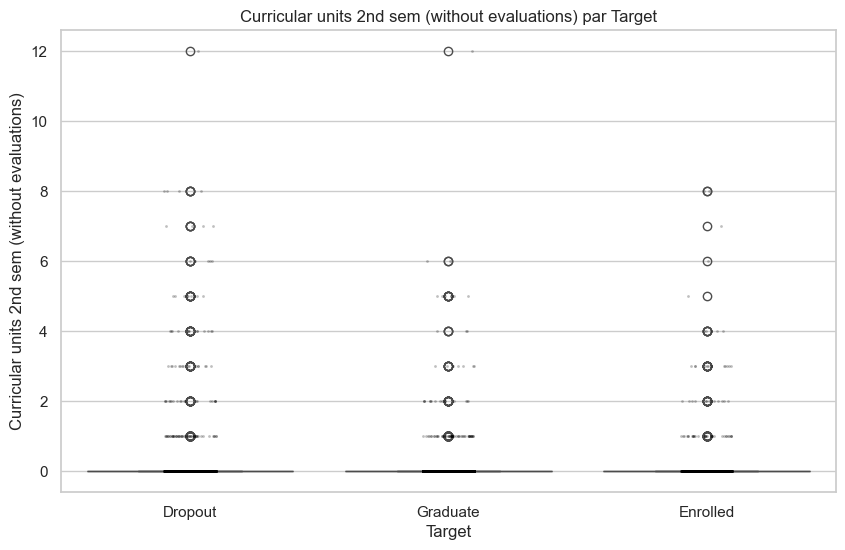

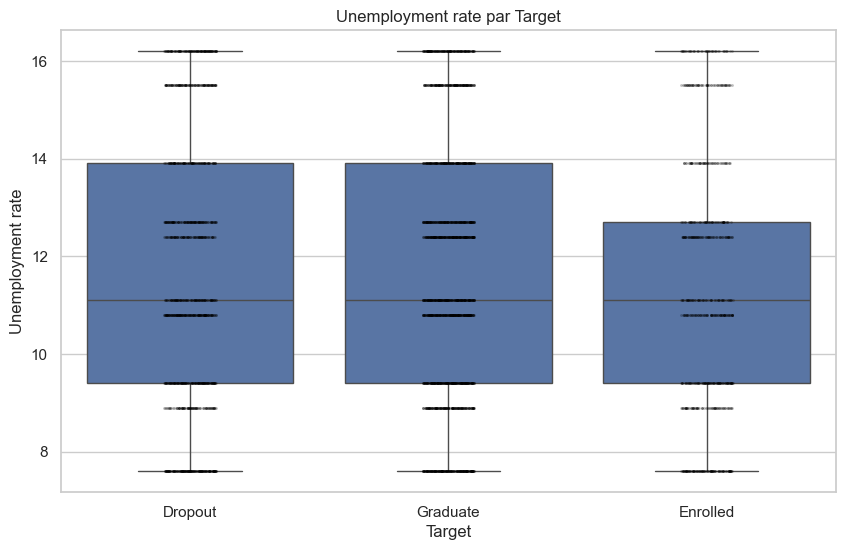

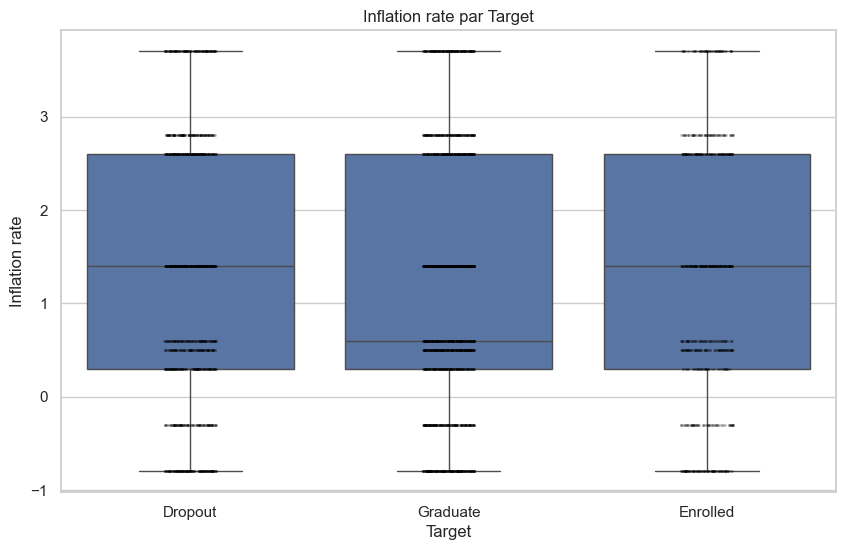

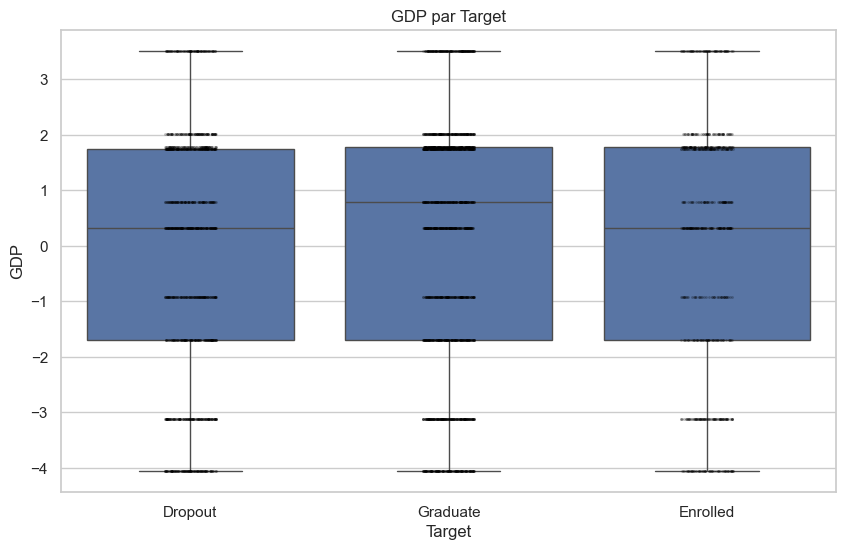

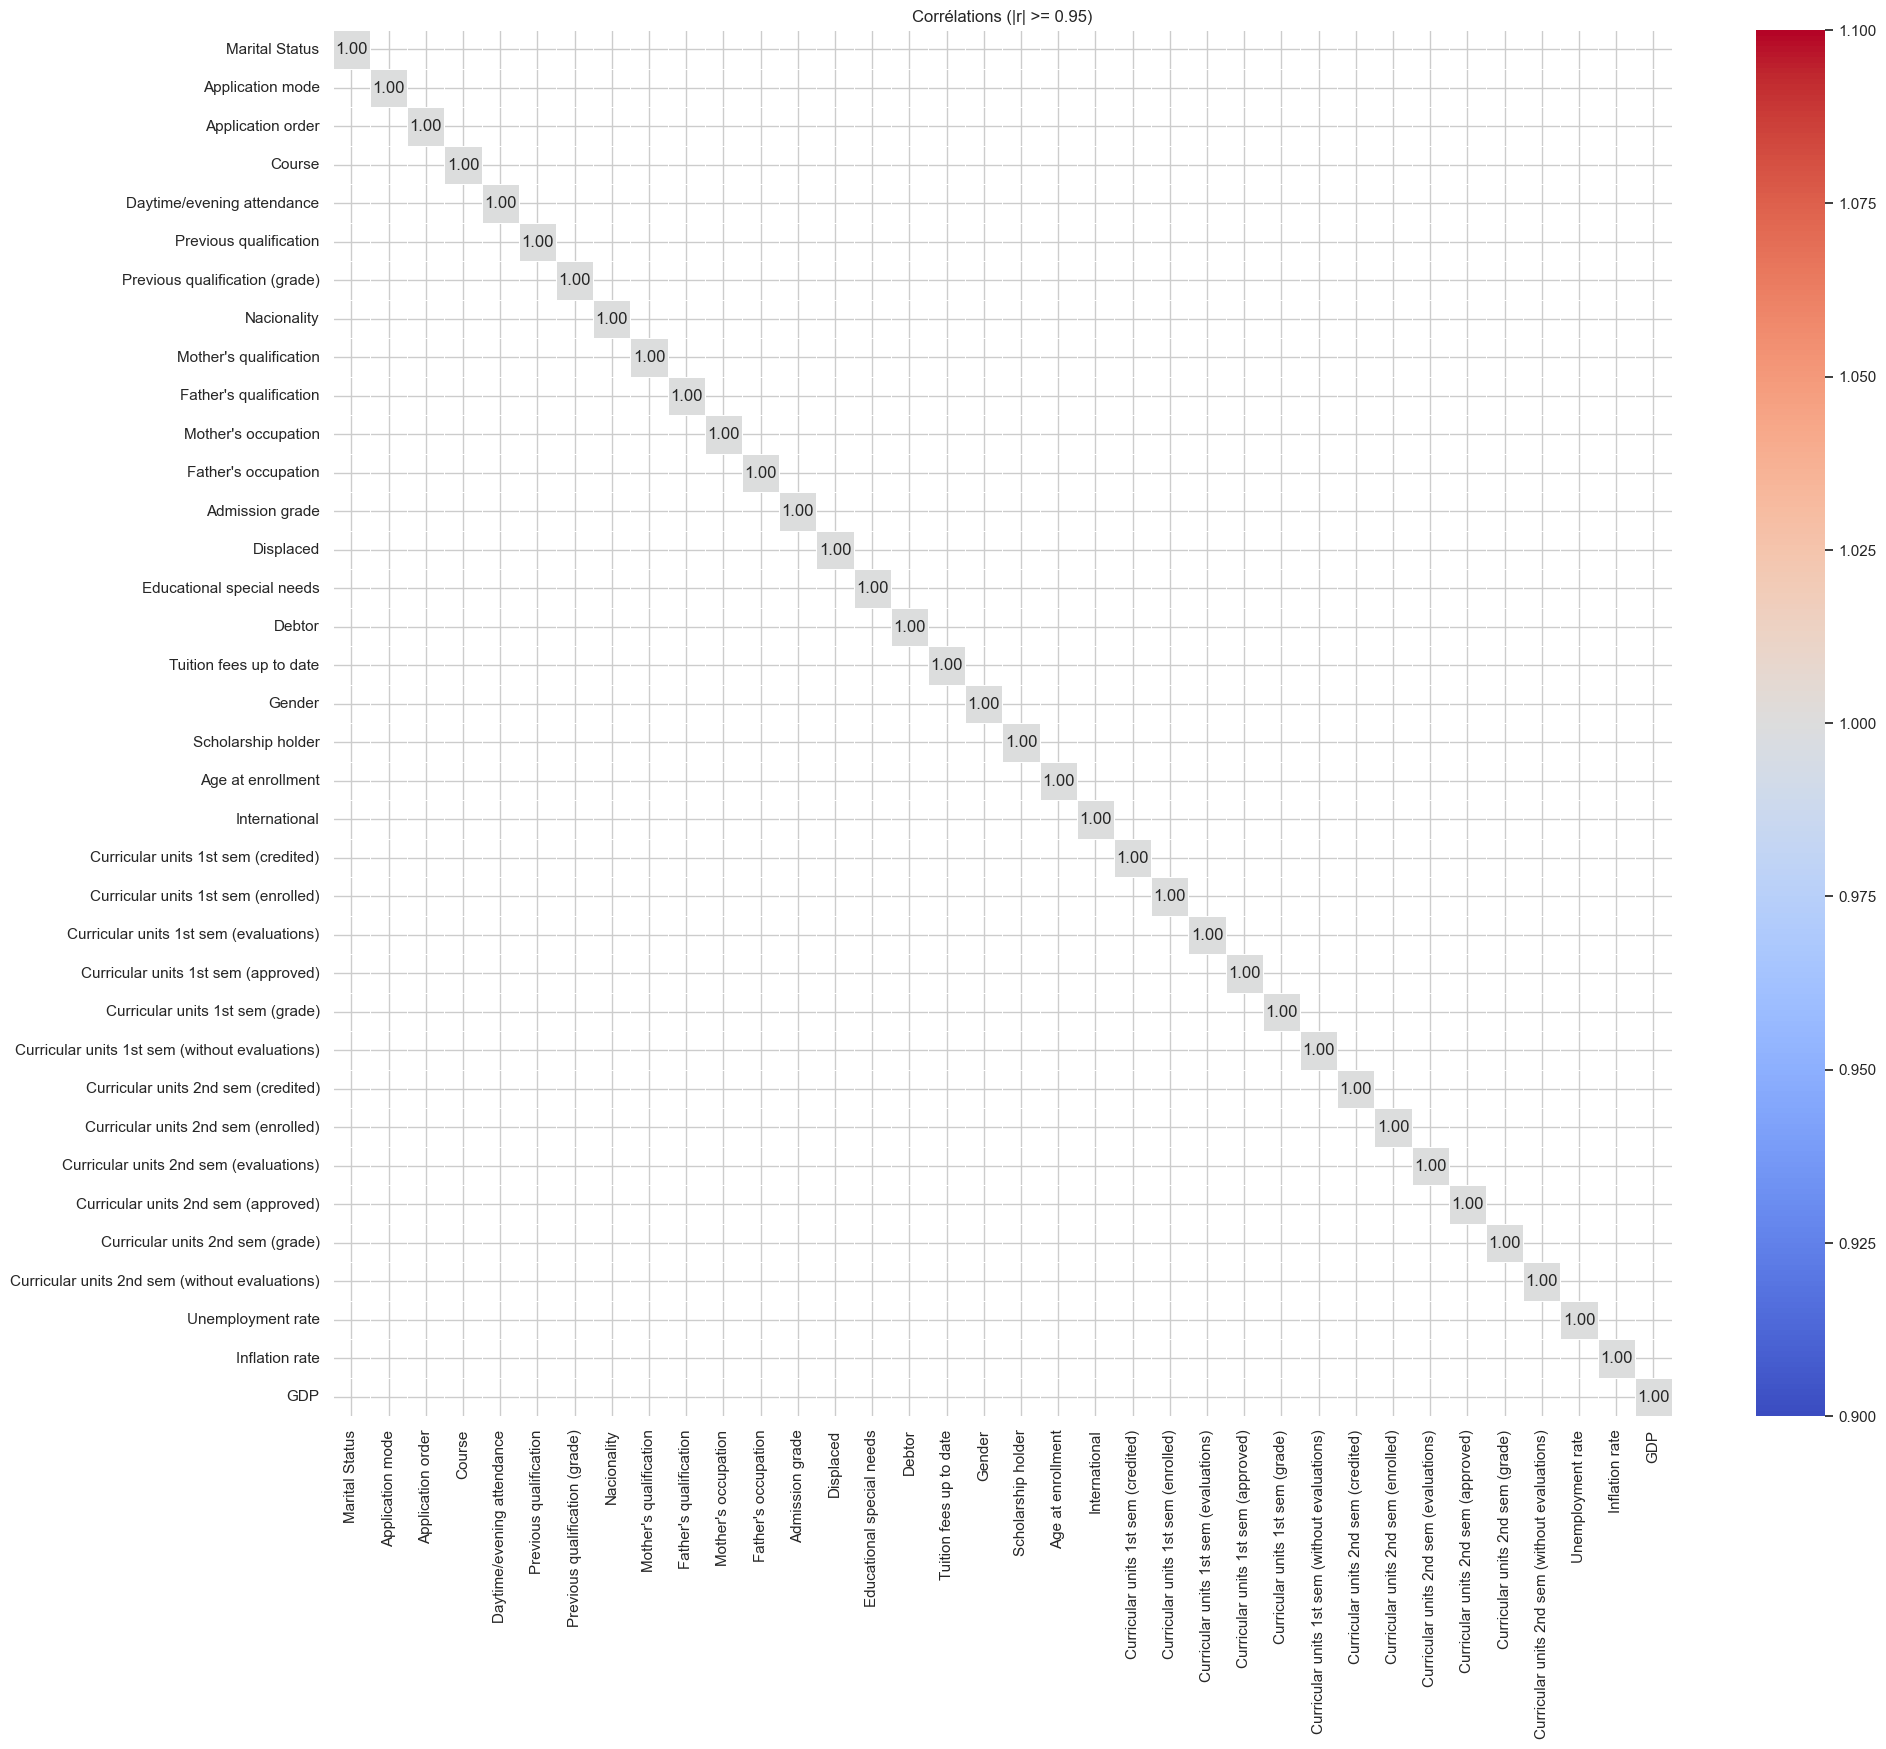

In [75]:
# Visualisations
sns.set(style="whitegrid")

# Boxplots par cible pour chaque colonne numérique
if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour les boxplots comparatifs.")
else:
    for col in numCols:
        plt.figure(figsize=figSize)
        sns.boxplot(data=df, x=targetColumn, y=col)
        sns.stripplot(data=df, x=targetColumn, y=col, color='black', alpha=0.25, size=2)
        plt.title(f"{col} par {targetColumn}")
        plt.show()

# Heatmap des corrélations numériques (seuil ajustable)
if len(numCols) >= 2:
    corr = df[numCols].corr(method='pearson')
    # Masquer les faibles corrélations en valeur absolue
    maskLow = corr.abs() < heatmapCorrThreshold
    corrMasked = corr.mask(maskLow)
    plt.figure(figsize=(max(8, len(numCols)*0.6), max(6, len(numCols)*0.5)))
    sns.heatmap(corrMasked, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5, linecolor='white', square=False)
    plt.title(f"Corrélations (|r| >= {heatmapCorrThreshold})")
    plt.show()
else:
    print("Corrélation: nécessite au moins 2 colonnes numériques.")


Comme les variables sont principalements qualitatives, la matrice de corrélation et les grahiques barplot ne donnent pas beaucoup d'informations et ne permet pas l'exclusion de variables.
Il faut privilégié une analyse bivariée et une MCA.

Analyse bivariée avec la cible:

Résultats de l'analyse bivariée (triés par Cramer's V):


,Variable,Chi²,p-value,Cramer's V,Mutual Information
31,Curricular units 2nd sem (grade),2908.0941798590,5.3758900040e-84,0.5732996500,0.3566223622
30,Curricular units 2nd sem (approved),2630.6352512460,0.0000000000e+00,0.5452651746,0.3160692606
25,Curricular units 1st sem (grade),2509.2157131040,3.1770791512e-44,0.5325328982,0.3135203523
24,Curricular units 1st sem (approved),2051.8175714121,0.0000000000e+00,0.4815560189,0.2469784452
16,Tuition fees up to date,823.5527243923,1.4716282631e-179,0.4314576215,0.0918280191
12,Admission grade,1436.5038834915,7.0262255264e-05,0.4029311518,0.1845816774
29,Curricular units 2nd sem (evaluations),868.5205119229,6.3811817679e-145,0.3133051133,0.0964026793
18,Scholarship holder,409.9430554470,9.5939303755e-90,0.3044067005,0.0491559423
23,Curricular units 1st sem (evaluations),812.2427801247,6.4177459238e-128,0.3029844730,0.0902629758
3,Course,558.2844739848,2.3165709041e-97,0.2511916612,0.0664675771



Interprétation Cramer's V:
  < 0.10 : Association négligeable
  0.10 - 0.30 : Association faible
  0.30 - 0.50 : Association modérée
  > 0.50 : Association forte


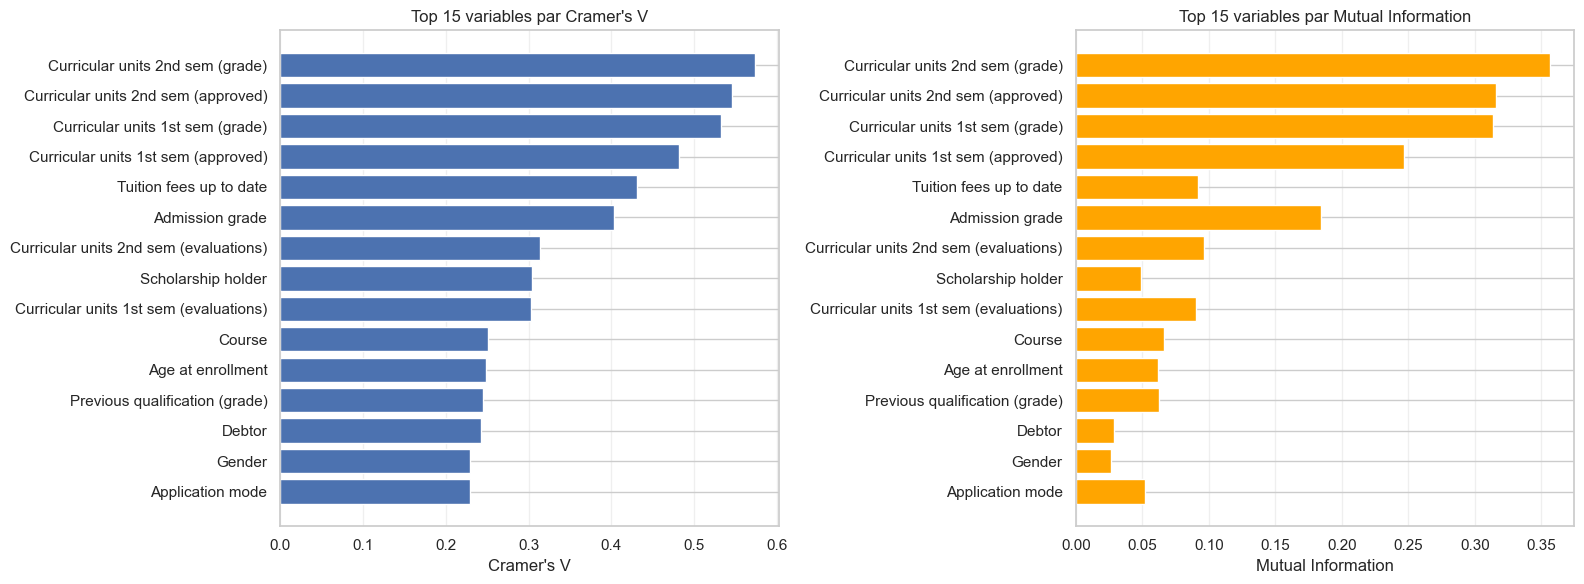


Variables avec association significative (p < 0.05): 33


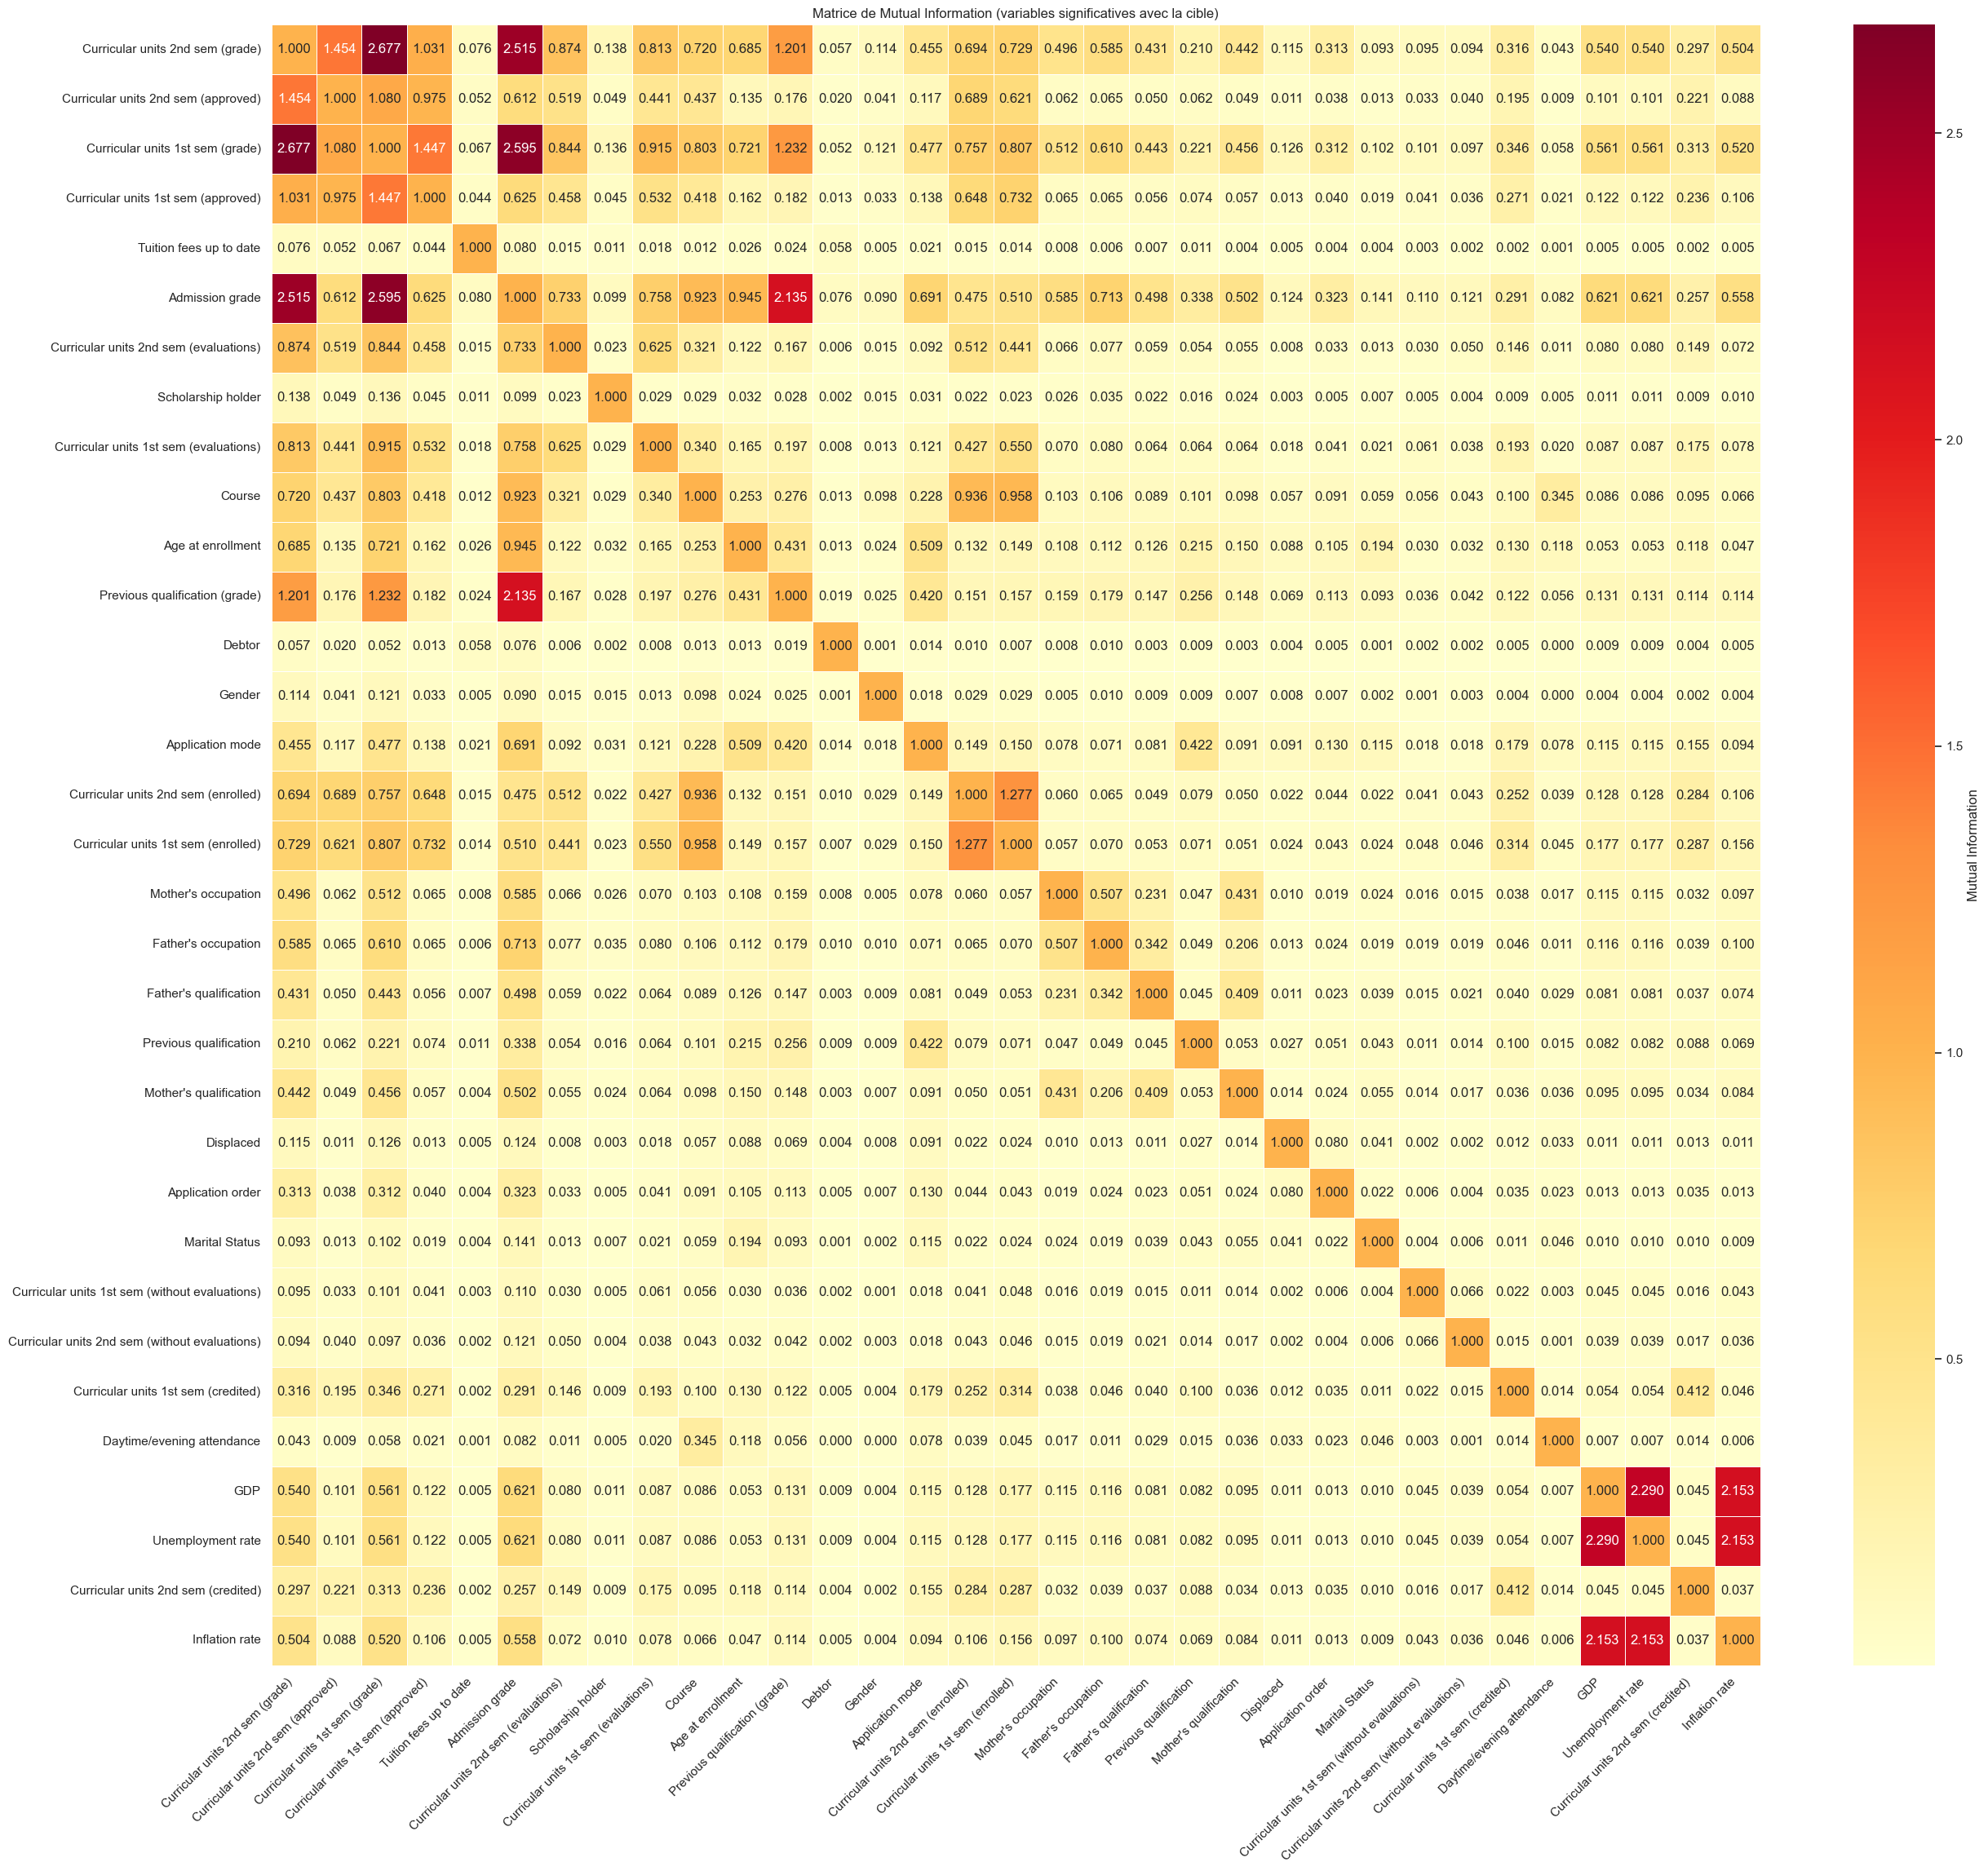

In [76]:
# Analyse bivariée : Chi², Cramer's V, Mutual Information

from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

def cramersV(contingencyTable):
    """
    Calcule le Cramer's V à partir d'une table de contingence.
    Cramer's V varie entre 0 (indépendance) et 1 (association parfaite).
    """
    chi2 = chi2_contingency(contingencyTable)[0]
    n = contingencyTable.sum().sum()
    minDim = min(contingencyTable.shape) - 1
    if minDim == 0 or n == 0:
        return 0.0
    return np.sqrt(chi2 / (n * minDim))


def calculateChi2AndCramersV(df, var1, var2):
    """
    Calcule le test Chi² et le Cramer's V entre deux variables catégorielles.
    """
    contingency = pd.crosstab(df[var1], df[var2])
    chi2, pValue, dof, expected = chi2_contingency(contingency)
    cramersVValue = cramersV(contingency)
    return {
        'chi2': chi2,
        'p_value': pValue,
        'dof': dof,
        'cramers_v': cramersVValue
    }


def calculateMutualInformation(df, var1, var2):
    """
    Calcule la Mutual Information entre deux variables.
    Nécessite d'encoder les variables catégorielles en entiers.
    """
    le1 = LabelEncoder()
    le2 = LabelEncoder()
    
    # Encoder les variables (gère les NaN en les remplaçant par une valeur spéciale)
    var1Encoded = le1.fit_transform(df[var1].fillna('NaN'))
    var2Encoded = le2.fit_transform(df[var2].fillna('NaN'))
    
    mi = mutual_info_score(var1Encoded, var2Encoded)
    return mi


if targetColumn is None or targetColumn not in df.columns:
    print("Définissez targetColumn pour l'analyse bivariée.")
else:
    # Variables à analyser (toutes les colonnes sauf la cible)
    variablesToAnalyze = [col for col in df.columns if col != targetColumn]
    
    # Résultats
    results = []
    
    print("Analyse bivariée avec la cible:")
    print("=" * 80)
    
    for var in variablesToAnalyze:
        try:
            # Chi² et Cramer's V (pour variables catégorielles)
            chi2Results = calculateChi2AndCramersV(df, var, targetColumn)
            
            # Mutual Information
            mi = calculateMutualInformation(df, var, targetColumn)
            
            results.append({
                'Variable': var,
                'Chi²': chi2Results['chi2'],
                'p-value': chi2Results['p_value'],
                "Cramer's V": chi2Results['cramers_v'],
                'Mutual Information': mi
            })
        except Exception as e:
            print(f"Erreur pour {var}: {e}")
            continue
    
    # Créer un DataFrame avec les résultats
    resultsDf = pd.DataFrame(results)
    
    # Trier par Cramer's V décroissant
    resultsDf = resultsDf.sort_values("Cramer's V", ascending=False)
    
    print("\nRésultats de l'analyse bivariée (triés par Cramer's V):")
    display(resultsDf)
    
    # Interprétation Cramer's V
    print("\nInterprétation Cramer's V:")
    print("  < 0.10 : Association négligeable")
    print("  0.10 - 0.30 : Association faible")
    print("  0.30 - 0.50 : Association modérée")
    print("  > 0.50 : Association forte")
    
    # Visualisation : Top variables par Cramer's V
    topN = min(15, len(resultsDf))
    topVars = resultsDf.head(topN)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphique Cramer's V
    axes[0].barh(range(len(topVars)), topVars["Cramer's V"].values)
    axes[0].set_yticks(range(len(topVars)))
    axes[0].set_yticklabels(topVars['Variable'].values)
    axes[0].set_xlabel("Cramer's V")
    axes[0].set_title(f"Top {topN} variables par Cramer's V")
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].invert_yaxis()
    
    # Graphique Mutual Information
    axes[1].barh(range(len(topVars)), topVars['Mutual Information'].values, color='orange')
    axes[1].set_yticks(range(len(topVars)))
    axes[1].set_yticklabels(topVars['Variable'].values)
    axes[1].set_xlabel("Mutual Information")
    axes[1].set_title(f"Top {topN} variables par Mutual Information")
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Heatmap des p-values du Chi² (pour variables significatives)
    significantVars = resultsDf[resultsDf['p-value'] < 0.05].copy()
    if len(significantVars) > 0:
        print(f"\nVariables avec association significative (p < 0.05): {len(significantVars)}")
        
        # Créer une matrice de Cramer's V pour les variables significatives
        if len(significantVars) > 1:
            miMatrix = np.zeros((len(significantVars), len(significantVars)))
            varNames = significantVars['Variable'].values
            
            for i, var1 in enumerate(varNames):
                for j, var2 in enumerate(varNames):
                    if i == j:
                        miMatrix[i, j] = 1.0
                    else:
                        try:
                            miVal = calculateMutualInformation(df, var1, var2)
                            miMatrix[i, j] = miVal
                        except:
                            miMatrix[i, j] = 0.0
            
            plt.figure(figsize=(max(10, len(significantVars)*0.8), max(8, len(significantVars)*0.7)))
            sns.heatmap(miMatrix, 
                       xticklabels=varNames, 
                       yticklabels=varNames,
                       annot=True, 
                       fmt=".3f", 
                       cmap="YlOrRd", 
                       linewidths=0.5,
                       cbar_kws={'label': 'Mutual Information'})
            plt.title("Matrice de Mutual Information (variables significatives avec la cible)")
            plt.xticks(rotation=45, ha='right')
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()


Variables exclues d’office (faible lien avec la cible + faible variance) :
- Nationality
- International
- Education special needs

Ces variables présentent une Mutual Information très faible avec la cible et/ou une variance très réduite, ce qui limite fortement leur potentiel prédictif.

Variables retirées pour manque de lien ou bruit :
- Daytime/evening attendance
- Application order
- Marital Status
- Displaced

Ces variables montrent peu de relation avec les résultats académiques ou le risque de dropout et introduisent davantage de bruit que d'information utile.


Choix parmi les variables académiques :

Je conserve les indicateurs réellement prédictifs :
- Curricular units 1st & 2nd sem : enrolled, evaluations, approved, grade

Je retire les versions :
- "(without evaluations)"
- "credited"

Ces dernières sont redondantes et moins informatives, comme visible dans la matrice de Mutual Information.

Regroupement ou simplification de variables macroéconomiques et parentales :
- GDP, unemployment rate, inflation rate : très corrélées entre elles et peu liées à la cible → possibilité de les regrouper en un indice économique ou de les exclure.
- Les professions des parents peuvent être regroupées en catégories plus synthétiques afin de réduire la sparsité et améliorer la lisibilité.

In [77]:
# Création d'un nouveau jeu de variables
# Exclusions, PCA macroéconomique, regroupement des professions

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Créer une copie du DataFrame original
dfNew = df.copy()

print("Création du nouveau jeu de variables")
print("=" * 80)

# 1. Variables à exclure (mentionnées dans l'analyse bivariée)
variablesToExclude = [
    "Nationality",
    "International", 
    "Educational special needs",
    "Daytime/evening attendance",
    "Application order",
    "Marital Status",
    "Displaced"
]

# Exclure aussi les versions "(without evaluations)" et "credited" des curricular units
# Identifier ces colonnes dynamiquement
curricularColsToExclude = [col for col in dfNew.columns 
                           if ("without evaluations" in col.lower() or 
                               "credited" in col.lower()) and 
                              "curricular units" in col.lower()]

allVarsToExclude = variablesToExclude + curricularColsToExclude

# Filtrer pour ne garder que les colonnes qui existent
existingVarsToExclude = [v for v in allVarsToExclude if v in dfNew.columns]

if existingVarsToExclude:
    print(f"\nVariables exclues ({len(existingVarsToExclude)}):")
    for var in existingVarsToExclude:
        print(f"  - {var}")
    dfNew = dfNew.drop(columns=existingVarsToExclude)
else:
    print("\nAucune variable à exclure trouvée (vérifiez les noms de colonnes)")

print(f"\nShape après exclusion: {dfNew.shape}")

# 2. PCA sur les variables macroéconomiques
macroEconomicVars = ["GDP", "Unemployment rate", "Inflation rate"]
# Vérifier les noms exacts dans le dataset
macroEconomicVarsFound = [v for v in macroEconomicVars if v in dfNew.columns]

if len(macroEconomicVarsFound) == 3:
    print(f"\nVariables macroéconomiques trouvées: {macroEconomicVarsFound}")
    
    # Extraire les variables macroéconomiques
    macroData = dfNew[macroEconomicVarsFound].copy()
    
    # Vérifier les valeurs manquantes
    if macroData.isna().sum().sum() > 0:
        print(f"  Valeurs manquantes détectées, remplacement par la médiane")
        macroData = macroData.fillna(macroData.median())
    
    # Standardiser les données
    scaler = StandardScaler()
    macroDataScaled = scaler.fit_transform(macroData)
    
    # Appliquer PCA (garder 1 composante principale)
    pca = PCA(n_components=1)
    macroPCA = pca.fit_transform(macroDataScaled)
    
    # Créer la nouvelle colonne
    dfNew["MacroEconomic_Index"] = macroPCA.flatten()
    
    # Supprimer les 3 variables originales
    dfNew = dfNew.drop(columns=macroEconomicVarsFound)
    
    print(f"  Variance expliquée par la 1ère composante: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"  Colonne créée: 'MacroEconomic_Index'")
    print(f"  Variables supprimées: {macroEconomicVarsFound}")
else:
    print(f"\nVariables macroéconomiques non trouvées ou incomplètes.")
    print(f"  Cherchées: {macroEconomicVars}")
    print(f"  Trouvées: {macroEconomicVarsFound}")
    print("  Vérifiez les noms exacts des colonnes dans le dataset")

# 3. Regroupement des professions des parents
# Mapping des professions en 3 classes
professionMapping = {
    # Classe 0 : Professions à haut niveau d'expertise / décision
    0: [1, 2, 122, 123, 125],
    # Classe 1 : Professions intermédiaires / techniques et administratives  
    1: [3, 4, 131, 132, 134, 141, 143, 144],
    # Classe 2 : Professions manuelles / services et ouvriers
    2: [5, 6, 7, 8, 9, 10, 151, 152, 153, 171, 173, 175, 191, 192, 193, 194]
}

# Créer le mapping inverse (code profession -> classe)
professionToClass = {}
for classe, professions in professionMapping.items():
    for prof in professions:
        professionToClass[prof] = classe

# Identifier les colonnes de professions des parents
motherOccupationCol = None
fatherOccupationCol = None

# Chercher les colonnes possibles
possibleMotherCols = [col for col in dfNew.columns if "mother" in col.lower() and "occupation" in col.lower()]
possibleFatherCols = [col for col in dfNew.columns if "father" in col.lower() and "occupation" in col.lower()]

if possibleMotherCols:
    motherOccupationCol = possibleMotherCols[0]
if possibleFatherCols:
    fatherOccupationCol = possibleFatherCols[0]

# Si pas trouvé, chercher d'autres variantes
if not motherOccupationCol:
    possibleMotherCols = [col for col in dfNew.columns if "mother" in col.lower() and ("occupation" in col.lower() or "profession" in col.lower())]
    if possibleMotherCols:
        motherOccupationCol = possibleMotherCols[0]

if not fatherOccupationCol:
    possibleFatherCols = [col for col in dfNew.columns if "father" in col.lower() and ("occupation" in col.lower() or "profession" in col.lower())]
    if possibleFatherCols:
        fatherOccupationCol = possibleFatherCols[0]

print(f"\nColonnes de professions trouvées:")
print(f"  Mère: {motherOccupationCol if motherOccupationCol else 'NON TROUVÉE'}")
print(f"  Père: {fatherOccupationCol if fatherOccupationCol else 'NON TROUVÉE'}")

# Appliquer le mapping
if motherOccupationCol and motherOccupationCol in dfNew.columns:
    dfNew["Mother_Occupation_Class"] = dfNew[motherOccupationCol].map(professionToClass).fillna(-1)
    # Remplacer -1 par la classe la plus fréquente pour les valeurs non mappées
    if (dfNew["Mother_Occupation_Class"] == -1).any():
        mostFrequentClass = dfNew["Mother_Occupation_Class"][dfNew["Mother_Occupation_Class"] != -1].mode()
        if len(mostFrequentClass) > 0:
            dfNew.loc[dfNew["Mother_Occupation_Class"] == -1, "Mother_Occupation_Class"] = mostFrequentClass[0]
    dfNew = dfNew.drop(columns=[motherOccupationCol])
    print(f"  Colonne créée: 'Mother_Occupation_Class' (0=Expertise, 1=Intermédiaire, 2=Manuelle)")
    print(f"  Distribution: {dfNew['Mother_Occupation_Class'].value_counts().to_dict()}")

if fatherOccupationCol and fatherOccupationCol in dfNew.columns:
    dfNew["Father_Occupation_Class"] = dfNew[fatherOccupationCol].map(professionToClass).fillna(-1)
    # Remplacer -1 par la classe la plus fréquente pour les valeurs non mappées
    if (dfNew["Father_Occupation_Class"] == -1).any():
        mostFrequentClass = dfNew["Father_Occupation_Class"][dfNew["Father_Occupation_Class"] != -1].mode()
        if len(mostFrequentClass) > 0:
            dfNew.loc[dfNew["Father_Occupation_Class"] == -1, "Father_Occupation_Class"] = mostFrequentClass[0]
    dfNew = dfNew.drop(columns=[fatherOccupationCol])
    print(f"  Colonne créée: 'Father_Occupation_Class' (0=Expertise, 1=Intermédiaire, 2=Manuelle)")
    print(f"  Distribution: {dfNew['Father_Occupation_Class'].value_counts().to_dict()}")

# 4. Regroupement des niveaux académiques (qualifications)
# Mapping des qualifications en 3 classes
qualificationMapping = {
    # Classe 0 : Niveau secondaire ou inférieur
    0: [1, 9, 10, 11, 12, 13, 14, 18, 19, 20, 22, 25, 26, 27, 29, 30, 31, 33, 35, 36, 37, 38],
    # Classe 1 : Niveau supérieur court / technique
    # Note: 31 est dans la classe 0 (niveau secondaire)
    1: [2, 3, 6, 39, 40, 41, 42],
    # Classe 2 : Niveau supérieur long / académique
    2: [4, 5, 43, 44]
}

# Créer le mapping inverse (code qualification -> classe)
qualificationToClass = {}
for classe, qualifications in qualificationMapping.items():
    for qual in qualifications:
        qualificationToClass[qual] = classe

# Identifier les colonnes de qualifications
previousQualificationCol = None
motherQualificationCol = None
fatherQualificationCol = None

# Chercher les colonnes possibles
possiblePreviousCols = [col for col in dfNew.columns if "previous" in col.lower() and "qualification" in col.lower()]
possibleMotherQualCols = [col for col in dfNew.columns if "mother" in col.lower() and "qualification" in col.lower()]
possibleFatherQualCols = [col for col in dfNew.columns if "father" in col.lower() and "qualification" in col.lower()]

if possiblePreviousCols:
    previousQualificationCol = possiblePreviousCols[0]
if possibleMotherQualCols:
    motherQualificationCol = possibleMotherQualCols[0]
if possibleFatherQualCols:
    fatherQualificationCol = possibleFatherQualCols[0]

print(f"\nColonnes de qualifications trouvées:")
print(f"  Étudiant (Previous): {previousQualificationCol if previousQualificationCol else 'NON TROUVÉE'}")
print(f"  Mère: {motherQualificationCol if motherQualificationCol else 'NON TROUVÉE'}")
print(f"  Père: {fatherQualificationCol if fatherQualificationCol else 'NON TROUVÉE'}")

# Appliquer le mapping pour la qualification précédente de l'étudiant
if previousQualificationCol and previousQualificationCol in dfNew.columns:
    dfNew["Previous_Qualification_Class"] = dfNew[previousQualificationCol].map(qualificationToClass).fillna(-1)
    # Remplacer -1 par la classe la plus fréquente pour les valeurs non mappées
    if (dfNew["Previous_Qualification_Class"] == -1).any():
        mostFrequentClass = dfNew["Previous_Qualification_Class"][dfNew["Previous_Qualification_Class"] != -1].mode()
        if len(mostFrequentClass) > 0:
            dfNew.loc[dfNew["Previous_Qualification_Class"] == -1, "Previous_Qualification_Class"] = mostFrequentClass[0]
    dfNew = dfNew.drop(columns=[previousQualificationCol])
    print(f"  Colonne créée: 'Previous_Qualification_Class' (0=Secondaire, 1=Supérieur court, 2=Supérieur long)")
    print(f"  Distribution: {dfNew['Previous_Qualification_Class'].value_counts().to_dict()}")

# Appliquer le mapping pour la qualification de la mère
if motherQualificationCol and motherQualificationCol in dfNew.columns:
    dfNew["Mother_Qualification_Class"] = dfNew[motherQualificationCol].map(qualificationToClass).fillna(-1)
    # Remplacer -1 par la classe la plus fréquente pour les valeurs non mappées
    if (dfNew["Mother_Qualification_Class"] == -1).any():
        mostFrequentClass = dfNew["Mother_Qualification_Class"][dfNew["Mother_Qualification_Class"] != -1].mode()
        if len(mostFrequentClass) > 0:
            dfNew.loc[dfNew["Mother_Qualification_Class"] == -1, "Mother_Qualification_Class"] = mostFrequentClass[0]
    dfNew = dfNew.drop(columns=[motherQualificationCol])
    print(f"  Colonne créée: 'Mother_Qualification_Class' (0=Secondaire, 1=Supérieur court, 2=Supérieur long)")
    print(f"  Distribution: {dfNew['Mother_Qualification_Class'].value_counts().to_dict()}")

# Appliquer le mapping pour la qualification du père
if fatherQualificationCol and fatherQualificationCol in dfNew.columns:
    dfNew["Father_Qualification_Class"] = dfNew[fatherQualificationCol].map(qualificationToClass).fillna(-1)
    # Remplacer -1 par la classe la plus fréquente pour les valeurs non mappées
    if (dfNew["Father_Qualification_Class"] == -1).any():
        mostFrequentClass = dfNew["Father_Qualification_Class"][dfNew["Father_Qualification_Class"] != -1].mode()
        if len(mostFrequentClass) > 0:
            dfNew.loc[dfNew["Father_Qualification_Class"] == -1, "Father_Qualification_Class"] = mostFrequentClass[0]
    dfNew = dfNew.drop(columns=[fatherQualificationCol])
    print(f"  Colonne créée: 'Father_Qualification_Class' (0=Secondaire, 1=Supérieur court, 2=Supérieur long)")
    print(f"  Distribution: {dfNew['Father_Qualification_Class'].value_counts().to_dict()}")

# Résumé final
print(f"\n{'='*80}")
print(f"Résumé de la transformation:")
print(f"  Shape original: {df.shape}")
print(f"  Shape nouveau: {dfNew.shape}")
print(f"  Colonnes supprimées: {df.shape[1] - dfNew.shape[1]}")
print(f"  Colonnes restantes: {dfNew.shape[1]}")

print(f"\nNouvelles colonnes créées:")
newCols = [col for col in dfNew.columns if col not in df.columns]
if newCols:
    for col in newCols:
        print(f"  - {col}")
else:
    print("  Aucune nouvelle colonne créée")

print(f"\nAperçu du nouveau dataset:")
display(dfNew.head(maxRowsToShow))
print(f"\nColonnes du nouveau dataset ({len(dfNew.columns)}):")
print(list(dfNew.columns))


Création du nouveau jeu de variables

Variables exclues (10):
  - International
  - Educational special needs
  - Daytime/evening attendance
  - Application order
  - Marital Status
  - Displaced
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (without evaluations)

Shape après exclusion: (4424, 27)

Variables macroéconomiques trouvées: ['GDP', 'Unemployment rate', 'Inflation rate']
  Variance expliquée par la 1ère composante: 0.449
  Colonne créée: 'MacroEconomic_Index'
  Variables supprimées: ['GDP', 'Unemployment rate', 'Inflation rate']

Colonnes de professions trouvées:
  Mère: Mother's occupation
  Père: Father's occupation
  Colonne créée: 'Mother_Occupation_Class' (0=Expertise, 1=Intermédiaire, 2=Manuelle)
  Distribution: {2.0: 2801, 1.0: 1193, 0.0: 430}
  Colonne créée: 'Father_Occupation_Class' (0=Expertise, 1=Intermédiaire, 2=Manuelle)
  Distribution: {2.0: 3305, 1

,Application mode,Course,Previous qualification (grade),Nacionality,Admission grade,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Target,MacroEconomic_Index,Mother_Occupation_Class,Father_Occupation_Class,Previous_Qualification_Class,Mother_Qualification_Class,Father_Qualification_Class
0,17,171,122.0,1,127.3,0,1,1,0,20,0,0,0,0.00000000,0,0,0,0.00000000,Dropout,0.7199578351,2.0,2.0,0.0,0.0,0.0
1,15,9254,160.0,1,142.5,0,0,1,0,19,6,6,6,14.00000000,6,6,6,13.66666667,Graduate,-0.1521245796,1.0,1.0,0.0,0.0,1.0
2,1,9070,122.0,1,124.8,0,0,1,0,19,6,0,0,0.00000000,6,0,0,0.00000000,Dropout,0.7199578351,2.0,2.0,0.0,0.0,0.0
3,17,9773,122.0,1,119.6,0,1,0,0,20,6,8,6,13.42857143,6,10,5,12.40000000,Graduate,-0.1738711140,2.0,1.0,0.0,0.0,0.0
4,39,8014,100.0,1,141.5,0,1,0,0,45,6,9,5,12.33333333,6,6,6,13.00000000,Graduate,-0.1521245796,2.0,2.0,0.0,0.0,0.0
5,39,9991,133.1,1,114.8,1,1,1,0,50,5,10,5,11.85714286,5,17,5,11.50000000,Graduate,-1.3514557499,2.0,2.0,0.0,0.0,0.0
6,1,9500,142.0,1,128.4,0,1,0,1,18,7,9,7,13.30000000,8,8,8,14.34500000,Graduate,-2.4783171158,2.0,2.0,0.0,0.0,0.0
7,18,9254,119.0,1,113.1,0,0,1,0,22,5,5,0,0.00000000,5,5,0,0.00000000,Dropout,-2.4783171158,2.0,2.0,0.0,0.0,0.0
8,1,9238,137.0,62,129.3,0,1,0,1,21,6,8,6,13.87500000,6,7,6,14.14285714,Graduate,-1.3514557499,2.0,2.0,0.0,0.0,0.0
9,1,9238,138.0,1,123.0,1,0,0,0,18,6,9,5,11.40000000,6,14,2,13.50000000,Dropout,1.7602929205,1.0,2.0,0.0,0.0,0.0



Colonnes du nouveau dataset (25):
['Application mode', 'Course', 'Previous qualification (grade)', 'Nacionality', 'Admission grade', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Target', 'MacroEconomic_Index', 'Mother_Occupation_Class', 'Father_Occupation_Class', 'Previous_Qualification_Class', 'Mother_Qualification_Class', 'Father_Qualification_Class']


Analyse des Correspondances Multiples (MCA)

Variables catégorielles sélectionnées pour la MCA (13):
['Application mode', 'Course', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Curricular units 2nd sem (approved)', 'MacroEconomic_Index', 'Mother_Occupation_Class', 'Father_Occupation_Class', 'Previous_Qualification_Class', 'Mother_Qualification_Class', 'Father_Qualification_Class']

Application de la MCA avec prince...

Valeurs propres et variance expliquée:


,Valeur propre,Variance expliquée (%),Variance cumulée (%)
0,0.2157799330,15.9822921004,15.9822921004
1,0.1757779073,13.0194398534,29.0017319537
2,0.1523654365,11.2853353797,40.2870673335
3,0.1354072338,10.0292827632,50.3163500967
4,0.1308402391,9.6910166291,60.0073667258
5,0.1166808018,8.6422617261,68.6496284520
6,0.1126708596,8.3452551163,76.9948835683
7,0.1081078713,8.0072857275,85.0021692957
8,0.1035765292,7.6716602954,92.6738295911
9,0.0989120053,7.3261704089,100.0000000000


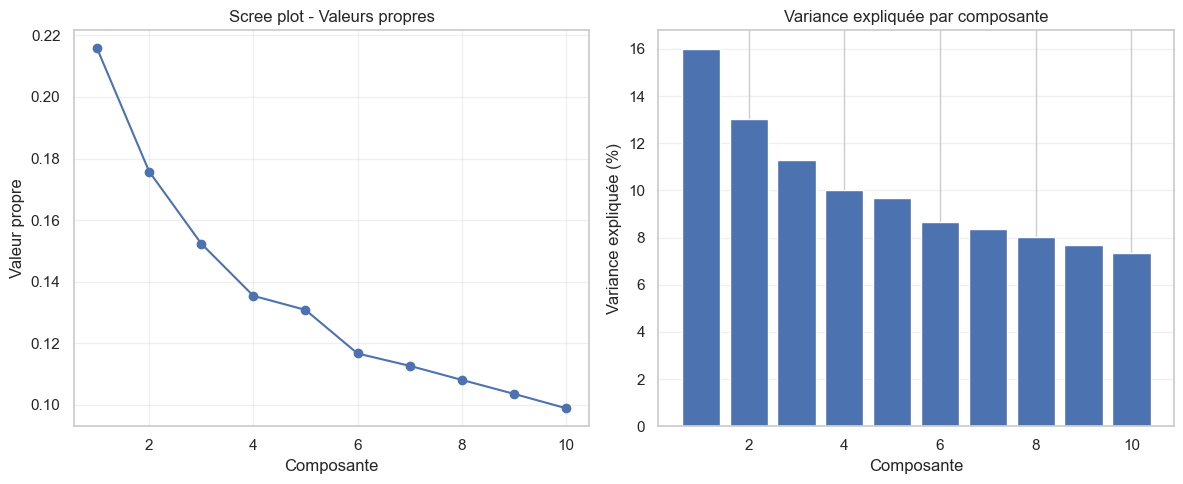

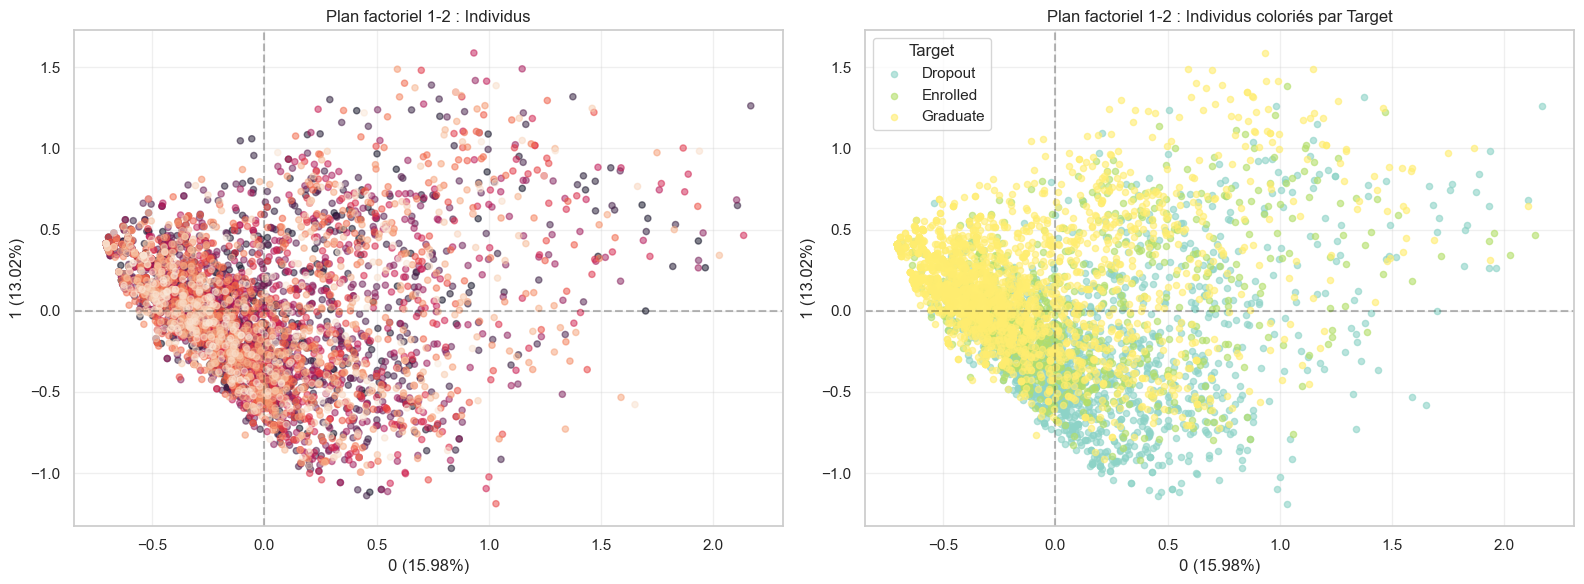


Affichage des 50 modalités les plus importantes (sur 88)


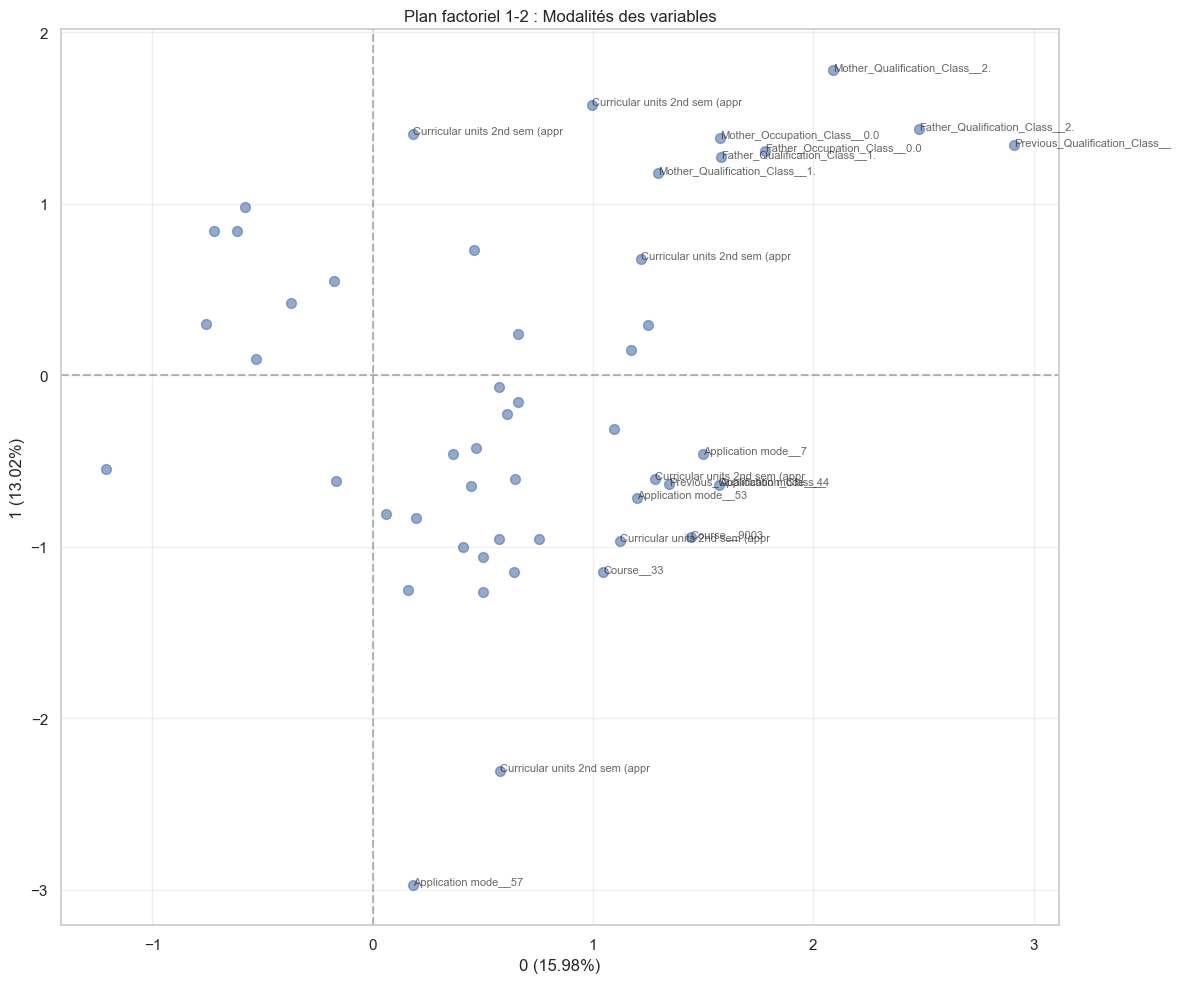


Contributions des modalités aux 2 premiers axes:


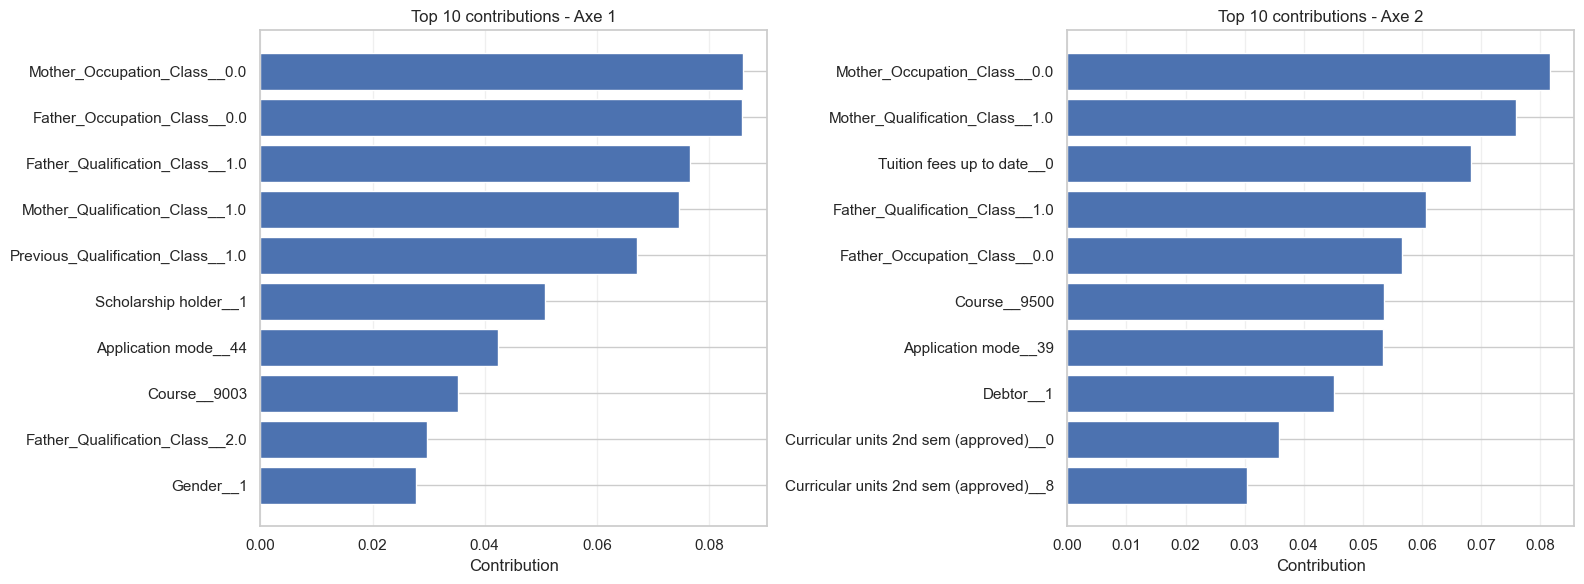


MCA terminée avec succès!
Nombre d'individus analysés: 4424
Nombre de modalités analysées: 88
Variance totale expliquée par les 2 premiers axes: 29.00%


In [78]:
# Analyse des Correspondances Multiples (MCA)

try:
    import prince
    PRINCE_AVAILABLE = True
except ImportError:
    PRINCE_AVAILABLE = False
    print("La bibliothèque 'prince' n'est pas installée.")
    print("Installez-la avec: pip install prince")
    print("Utilisation d'une implémentation alternative avec sklearn...")

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

print("Analyse des Correspondances Multiples (MCA)")
print("=" * 80)

# Sélectionner les variables catégorielles du nouveau dataset (exclure la cible et les variables numériques)
# Identifier les variables catégorielles dans dfNew
if 'dfNew' not in locals():
    print("Erreur: dfNew n'existe pas. Exécutez d'abord la cellule de création du nouveau jeu de variables.")
else:
    # Détecter les variables catégorielles
    categoricalVarsMCA = []
    numericVarsMCA = []
    
    for col in dfNew.columns:
        if col == targetColumn:
            continue  # Exclure la cible
        if dfNew[col].dtype in ['object', 'category'] or dfNew[col].dtype.name == 'category':
            categoricalVarsMCA.append(col)
        elif dfNew[col].dtype in ['int64', 'int32', 'float64', 'float32']:
            # Vérifier si c'est vraiment numérique ou une variable catégorielle encodée
            nUnique = dfNew[col].nunique()
            if nUnique <= 20:  # Si peu de valeurs uniques, considérer comme catégorielle
                categoricalVarsMCA.append(col)
            else:
                numericVarsMCA.append(col)
        else:
            categoricalVarsMCA.append(col)
    
    print(f"\nVariables catégorielles sélectionnées pour la MCA ({len(categoricalVarsMCA)}):")
    print(categoricalVarsMCA)
    
    if len(categoricalVarsMCA) < 2:
        print("\nErreur: Il faut au moins 2 variables catégorielles pour effectuer une MCA.")
    else:
        # Préparer les données pour la MCA
        dfMCA = dfNew[categoricalVarsMCA].copy()
        
        # Encoder les variables catégorielles si nécessaire
        dfMCAEncoded = dfMCA.copy()
        encoders = {}
        for col in dfMCAEncoded.columns:
            if dfMCAEncoded[col].dtype == 'object' or dfMCAEncoded[col].dtype.name == 'category':
                le = LabelEncoder()
                dfMCAEncoded[col] = le.fit_transform(dfMCAEncoded[col].astype(str).fillna('NaN'))
                encoders[col] = le
        
        # Remplacer les NaN par des valeurs appropriées
        dfMCAEncoded = dfMCAEncoded.fillna(dfMCAEncoded.mode().iloc[0] if len(dfMCAEncoded.mode()) > 0 else 0)
        
        if PRINCE_AVAILABLE:
            # Utiliser prince pour la MCA
            print("\nApplication de la MCA avec prince...")
            mca = prince.MCA(n_components=10, n_iter=3, random_state=randomSeed)
            mca = mca.fit(dfMCA)
            
            # Coordonnées des individus
            individualsCoords = mca.row_coordinates(dfMCA)
            
            # Coordonnées des variables (modalités)
            variablesCoords = mca.column_coordinates(dfMCA)
            
            # Valeurs propres (eigenvalues)
            eigenvalues = mca.eigenvalues_
            
            # Pourcentages de variance expliquée (calculée à partir des valeurs propres)
            # La variance expliquée est la proportion de chaque valeur propre par rapport à la somme totale
            totalInertia = eigenvalues.sum()
            explainedVariance = eigenvalues / totalInertia if totalInertia > 0 else eigenvalues
            
        else:
            # Implémentation alternative avec sklearn (approximation)
            print("\nApplication d'une PCA sur données encodées (approximation MCA)...")
            pca = PCA(n_components=min(10, len(dfMCAEncoded.columns), len(dfMCAEncoded)-1), random_state=randomSeed)
            pcaFit = pca.fit(dfMCAEncoded)
            
            individualsCoords = pd.DataFrame(
                pcaFit.transform(dfMCAEncoded),
                index=dfMCAEncoded.index,
                columns=[f'PC{i+1}' for i in range(pcaFit.n_components_)]
            )
            
            # Pour l'approximation, on utilise les composantes principales
            variablesCoords = pd.DataFrame(
                pcaFit.components_.T,
                index=dfMCAEncoded.columns,
                columns=[f'PC{i+1}' for i in range(pcaFit.n_components_)]
            )
            
            eigenvalues = pcaFit.explained_variance_
            explainedVariance = pcaFit.explained_variance_ratio_
        
        # Afficher les résultats
        print(f"\nValeurs propres et variance expliquée:")
        eigenDf = pd.DataFrame({
            'Valeur propre': eigenvalues[:10],
            'Variance expliquée (%)': explainedVariance[:10] * 100,
            'Variance cumulée (%)': np.cumsum(explainedVariance[:10]) * 100
        })
        display(eigenDf.head(10))
        
        # Graphique du scree plot
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(range(1, min(11, len(eigenvalues)+1)), eigenvalues[:10], 'bo-')
        plt.xlabel('Composante')
        plt.ylabel('Valeur propre')
        plt.title('Scree plot - Valeurs propres')
        plt.grid(True, alpha=0.3)
        
        plt.subplot(1, 2, 2)
        plt.bar(range(1, min(11, len(explainedVariance)+1)), explainedVariance[:10] * 100)
        plt.xlabel('Composante')
        plt.ylabel('Variance expliquée (%)')
        plt.title('Variance expliquée par composante')
        plt.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        # Graphique des individus sur les 2 premiers axes
        if len(individualsCoords.columns) >= 2:
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            
            ax1 = axes[0]
            scatter = ax1.scatter(individualsCoords.iloc[:, 0], individualsCoords.iloc[:, 1], 
                                 alpha=0.5, s=20, c=range(len(individualsCoords)))
            ax1.set_xlabel(f'{individualsCoords.columns[0]} ({explainedVariance[0]*100:.2f}%)')
            ax1.set_ylabel(f'{individualsCoords.columns[1]} ({explainedVariance[1]*100:.2f}%)')
            ax1.set_title('Plan factoriel 1-2 : Individus')
            ax1.grid(True, alpha=0.3)
            ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
            ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
            
            # Colorier par cible si disponible
            if targetColumn and targetColumn in dfNew.columns:
                ax2 = axes[1]
                targetValues = dfNew[targetColumn].values
                uniqueTargets = np.unique(targetValues)
                colors = plt.cm.Set3(np.linspace(0, 1, len(uniqueTargets)))
                
                for i, target in enumerate(uniqueTargets):
                    mask = targetValues == target
                    ax2.scatter(individualsCoords.iloc[mask, 0], individualsCoords.iloc[mask, 1],
                              alpha=0.6, s=20, label=str(target), c=[colors[i]])
                
                ax2.set_xlabel(f'{individualsCoords.columns[0]} ({explainedVariance[0]*100:.2f}%)')
                ax2.set_ylabel(f'{individualsCoords.columns[1]} ({explainedVariance[1]*100:.2f}%)')
                ax2.set_title(f'Plan factoriel 1-2 : Individus coloriés par {targetColumn}')
                ax2.legend(title=targetColumn)
                ax2.grid(True, alpha=0.3)
                ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
                ax2.axvline(x=0, color='k', linestyle='--', alpha=0.3)
            else:
                axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
        
        # Graphique des variables (modalités) sur les 2 premiers axes
        if len(variablesCoords.columns) >= 2 and len(variablesCoords) > 0:
            plt.figure(figsize=(12, 10))
            
            # Afficher un échantillon des modalités pour éviter la surcharge
            maxModalities = 50
            if len(variablesCoords) > maxModalities:
                # Sélectionner les modalités les plus importantes (distance à l'origine)
                distances = np.sqrt(variablesCoords.iloc[:, 0]**2 + variablesCoords.iloc[:, 1]**2)
                topModalities = distances.nlargest(maxModalities).index
                variablesCoordsDisplay = variablesCoords.loc[topModalities]
                print(f"\nAffichage des {maxModalities} modalités les plus importantes (sur {len(variablesCoords)})")
            else:
                variablesCoordsDisplay = variablesCoords
            
            plt.scatter(variablesCoordsDisplay.iloc[:, 0], variablesCoordsDisplay.iloc[:, 1], 
                       alpha=0.6, s=50)
            
            # Annoter quelques points
            for idx in variablesCoordsDisplay.index[:20]:  # Annoter les 20 premiers
                plt.annotate(str(idx)[:30], 
                           (variablesCoordsDisplay.loc[idx, variablesCoordsDisplay.columns[0]],
                            variablesCoordsDisplay.loc[idx, variablesCoordsDisplay.columns[1]]),
                           fontsize=8, alpha=0.7)
            
            plt.xlabel(f'{variablesCoords.columns[0]} ({explainedVariance[0]*100:.2f}%)')
            plt.ylabel(f'{variablesCoords.columns[1]} ({explainedVariance[1]*100:.2f}%)')
            plt.title('Plan factoriel 1-2 : Modalités des variables')
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
            plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        # Contributions des variables aux axes principaux
        if PRINCE_AVAILABLE and hasattr(mca, 'column_contributions_'):
            print("\nContributions des modalités aux 2 premiers axes:")
            contributions = mca.column_contributions_
            if contributions is not None and len(contributions) > 0:
                topContribAxis1 = contributions.iloc[:, 0].abs().nlargest(10)
                topContribAxis2 = contributions.iloc[:, 1].abs().nlargest(10)
                
                fig, axes = plt.subplots(1, 2, figsize=(16, 6))
                
                axes[0].barh(range(len(topContribAxis1)), topContribAxis1.values)
                axes[0].set_yticks(range(len(topContribAxis1)))
                axes[0].set_yticklabels([str(x)[:40] for x in topContribAxis1.index])
                axes[0].set_xlabel('Contribution')
                axes[0].set_title(f'Top 10 contributions - Axe 1')
                axes[0].invert_yaxis()
                axes[0].grid(True, alpha=0.3, axis='x')
                
                axes[1].barh(range(len(topContribAxis2)), topContribAxis2.values)
                axes[1].set_yticks(range(len(topContribAxis2)))
                axes[1].set_yticklabels([str(x)[:40] for x in topContribAxis2.index])
                axes[1].set_xlabel('Contribution')
                axes[1].set_title(f'Top 10 contributions - Axe 2')
                axes[1].invert_yaxis()
                axes[1].grid(True, alpha=0.3, axis='x')
                
                plt.tight_layout()
                plt.show()
        
        print(f"\n{'='*80}")
        print("MCA terminée avec succès!")
        print(f"Nombre d'individus analysés: {len(individualsCoords)}")
        print(f"Nombre de modalités analysées: {len(variablesCoords)}")
        print(f"Variance totale expliquée par les 2 premiers axes: {sum(explainedVariance[:2])*100:.2f}%")


## Interprétation des résultats de la MCA

**Qualité de la représentation :**

La variance expliquée par les 2 premiers axes factoriels indique la qualité de la représentation des données dans le plan factoriel. Une variance expliquée élevée (>30%) suggère que les deux premiers axes capturent bien la structure des données, tandis qu'une variance plus faible nécessite l'examen d'axes supplémentaires.

**Plan factoriel 1-2 : Individus**

L'analyse des positions des individus sur le plan factoriel permet d'identifier :
- Des groupes d'étudiants avec des profils similaires (proximité spatiale)
- Des étudiants atypiques (positions éloignées du centre)
- La séparation potentielle entre les différentes classes de la cible (dropout, enrolled, graduate)

Si les individus coloriés par la cible montrent une séparation claire, cela indique que les variables catégorielles permettent de discriminer les différents résultats académiques.

**Plan factoriel 1-2 : Modalités**

L'analyse des modalités révèle :
- Les associations entre modalités de variables différentes (proximité = association)
- Les oppositions entre modalités (positions opposées sur les axes)
- Les modalités les plus contributives à la formation des axes (éloignées de l'origine)

Les modalités proches du centre (origine) sont peu discriminantes, tandis que celles éloignées contribuent fortement à la structure des axes.

**Contributions des modalités**

Les contributions indiquent quelles modalités sont les plus importantes pour expliquer chaque axe factoriel. Les modalités avec les contributions les plus élevées définissent la signification de chaque axe :
- Axe 1 : généralement capture la dimension principale de variation
- Axe 2 : capture la deuxième dimension de variation, souvent orthogonale à la première

**Interprétation pratique :**

Pour le contexte académique, les axes peuvent représenter des dimensions telles que :
- Niveau socio-économique (qualifications et professions des parents)
- Parcours académique (qualification précédente, cours, résultats)
- Situation financière (boursier, débiteur, frais à jour)
- Performance académique (unités curriculaires approuvées)

L'interprétation des axes doit être faite en examinant les modalités les plus contributives et leur position relative sur le plan factoriel.


In [79]:
# Identification des 9 variables expliquant 100% de la variance dans la MCA

print("Identification des variables pour réduction dimensionnelle")
print("=" * 80)

# Vérifier que la MCA a été exécutée
if 'mca' in locals() and 'explainedVariance' in locals() and 'categoricalVarsMCA' in locals():
    # Calculer la variance cumulée
    cumulativeVariance = np.cumsum(explainedVariance) * 100
    
    # Trouver le nombre de composantes nécessaires pour 100%
    nComponentsFor100 = np.where(cumulativeVariance >= 99.99)[0]
    if len(nComponentsFor100) > 0:
        nComponentsNeeded = nComponentsFor100[0] + 1
        print(f"\nNombre de composantes nécessaires pour expliquer ~100% de la variance: {nComponentsNeeded}")
        print(f"Variance cumulée avec {nComponentsNeeded} composantes: {cumulativeVariance[nComponentsNeeded-1]:.2f}%")
    else:
        nComponentsNeeded = len(explainedVariance)
        print(f"\nToutes les composantes nécessaires pour expliquer la variance totale")
        print(f"Nombre total de composantes: {nComponentsNeeded}")
    
    # Identifier les variables les plus importantes
    if PRINCE_AVAILABLE and hasattr(mca, 'column_contributions_'):
        contributions = mca.column_contributions_
        if contributions is not None and len(contributions) > 0:
            # Calculer les contributions par variable
            variableContributions = {}
            
            for var in categoricalVarsMCA:
                # Trouver toutes les modalités de cette variable
                varModalities = [idx for idx in contributions.index 
                               if str(var).lower() in str(idx).lower()]
                
                if len(varModalities) == 0:
                    # Essayer une recherche plus large
                    varModalities = [idx for idx in contributions.index if var in str(idx)]
                
                if len(varModalities) > 0:
                    # Contribution totale sur les composantes nécessaires
                    totalContribution = 0
                    for comp in range(min(nComponentsNeeded, len(contributions.columns))):
                        varContrib = contributions.loc[varModalities, contributions.columns[comp]].abs().sum()
                        totalContribution += varContrib
                    variableContributions[var] = totalContribution
                else:
                    variableContributions[var] = 0
            
            # Trier par contribution décroissante
            sortedVars = sorted(variableContributions.items(), key=lambda x: x[1], reverse=True)
            
            print(f"\nContributions totales des variables aux {nComponentsNeeded} premières composantes:")
            for var, contrib in sortedVars:
                print(f"  {var}: {contrib:.4f}")
            
            # Sélectionner les top 9 variables
            selectedVars = [var for var, _ in sortedVars[:9]]
            cumulativeContrib = sum(contrib for _, contrib in sortedVars[:9])
            
            print(f"\n{'='*80}")
            print(f"TOP 9 VARIABLES EXPLIQUANT ~100% DE LA VARIANCE:")
            print("=" * 80)
            for i, var in enumerate(selectedVars, 1):
                print(f"  {i}. {var}")
            print(f"\nContribution cumulée de ces 9 variables: {cumulativeContrib:.4f}")
            print(f"Nombre de composantes utilisées: {nComponentsNeeded}")
            
            # Stocker les variables sélectionnées
            top9Variables = selectedVars
            print(f"\nVariables stockées dans 'top9Variables'")
        else:
            print("\nImpossible d'accéder aux contributions des modalités")
    else:
        print("\nUtilisation d'une méthode alternative basée sur les coordonnées")
        if 'variablesCoords' in locals():
            varImportance = {}
            for var in categoricalVarsMCA:
                varModalities = [idx for idx in variablesCoords.index 
                               if str(var).lower() in str(idx).lower()]
                
                if len(varModalities) == 0:
                    varModalities = [idx for idx in variablesCoords.index if var in str(idx)]
                
                if len(varModalities) > 0:
                    importance = np.sqrt((variablesCoords.loc[varModalities, :nComponentsNeeded]**2).sum(axis=1)).mean()
                    varImportance[var] = importance
                else:
                    varImportance[var] = 0
            
            sortedVars = sorted(varImportance.items(), key=lambda x: x[1], reverse=True)
            selectedVars = [var for var, _ in sortedVars[:9]]
            
            print(f"\nTop 9 variables par importance:")
            for i, var in enumerate(selectedVars, 1):
                print(f"  {i}. {var}")
            top9Variables = selectedVars
else:
    print("Erreur: La MCA n'a pas été exécutée. Exécutez d'abord la cellule MCA.")


Identification des variables pour réduction dimensionnelle

Nombre de composantes nécessaires pour expliquer ~100% de la variance: 10
Variance cumulée avec 10 composantes: 100.00%

Contributions totales des variables aux 10 premières composantes:
  Application mode: 2.3587
  Curricular units 2nd sem (approved): 2.3145
  Course: 1.7358
  MacroEconomic_Index: 0.9188
  Previous_Qualification_Class: 0.5494
  Mother_Occupation_Class: 0.4446
  Father_Occupation_Class: 0.4185
  Mother_Qualification_Class: 0.2956
  Father_Qualification_Class: 0.2745
  Tuition fees up to date: 0.1912
  Gender: 0.1808
  Scholarship holder: 0.1606
  Debtor: 0.1568

TOP 9 VARIABLES EXPLIQUANT ~100% DE LA VARIANCE:
  1. Application mode
  2. Curricular units 2nd sem (approved)
  3. Course
  4. MacroEconomic_Index
  5. Previous_Qualification_Class
  6. Mother_Occupation_Class
  7. Father_Occupation_Class
  8. Mother_Qualification_Class
  9. Father_Qualification_Class

Contribution cumulée de ces 9 variables: 9.3105


In [80]:
# One-Hot Encoding et préparation des données pour l'entraînement
# ================================================================
# Cette cellule effectue :
# 1. One-hot encoding de la TARGET (obligatoire, sans drop_first)
# 2. One-hot encoding des features catégorielles avec peu de modalités (avec drop_first pour éviter multicolinéarité)
# 3. Label encoding pour les variables avec beaucoup de modalités
# 4. Normalisation des variables numériques
# 5. Train/Test/Validation split

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

print("=" * 80)
print("ONE-HOT ENCODING ET PRÉPARATION DES DONNÉES")
print("=" * 80)

# Vérifier que dfNew existe
if 'dfNew' not in locals():
    raise ValueError("dfNew n'existe pas. Exécutez d'abord la cellule de création du nouveau jeu de variables (Cell 14).")

# Vérifier que targetColumn existe
if targetColumn not in dfNew.columns:
    raise ValueError(f"La colonne cible '{targetColumn}' n'existe pas dans dfNew.")

# ============================================
# 1. ONE-HOT ENCODING DE LA TARGET (OBLIGATOIRE)
# ============================================
print("\n1. One-Hot Encoding de la TARGET")
print("-" * 80)

# Extraire la target
y_raw = dfNew[targetColumn].values.reshape(-1, 1)

# One-hot encoder la target (SANS drop_first car on veut toutes les classes)
targetEncoder = OneHotEncoder(sparse_output=False, drop=None)
y_onehot = targetEncoder.fit_transform(y_raw)

# Obtenir les noms des classes
classNames = targetEncoder.categories_[0]
print(f"Classes de la target: {classNames}")
print(f"Shape de y_onehot: {y_onehot.shape}")

# Vérification : chaque ligne doit sommer à 1
assert np.allclose(y_onehot.sum(axis=1), 1.0), "Erreur: y_onehot doit sommer à 1 par ligne"
print("✓ Vérification: chaque ligne de y_onehot somme à 1")

# ============================================
# 2. PRÉPARATION DES FEATURES
# ============================================
print("\n2. Préparation des Features")
print("-" * 80)

# Vérifier si top9Variables existe et filtrer les features
if 'top9Variables' in locals() and top9Variables is not None:
    print(f"\n✓ Utilisation des {len(top9Variables)} variables présélectionnées par l'EDA:")
    for i, var in enumerate(top9Variables, 1):
        print(f"  {i}. {var}")
    
    # Vérifier que toutes les variables existent dans dfNew
    availableVars = [var for var in top9Variables if var in dfNew.columns]
    missingVars = [var for var in top9Variables if var not in dfNew.columns]
    
    if missingVars:
        print(f"\n⚠️  ATTENTION: {len(missingVars)} variable(s) manquante(s) dans dfNew:")
        for var in missingVars:
            print(f"    - {var}")
        print("   Utilisation des variables disponibles uniquement.")
    
    if len(availableVars) == 0:
        print("\n⚠️  Aucune variable présélectionnée trouvée dans dfNew.")
        print("   Utilisation de toutes les variables disponibles.")
        X_df = dfNew.drop(columns=[targetColumn])
    else:
        # Filtrer pour ne garder que les 9 variables présélectionnées + Target
        featuresToKeep = availableVars + [targetColumn]
        X_df = dfNew[featuresToKeep].drop(columns=[targetColumn])
        print(f"\n✓ {len(availableVars)} variables présélectionnées utilisées pour l'entraînement")
        if len(availableVars) < len(top9Variables):
            print(f"  ({len(top9Variables) - len(availableVars)} variable(s) manquante(s))")
else:
    print("\n⚠️  top9Variables n'existe pas ou est None.")
    print("   Utilisation de toutes les variables disponibles.")
    print("   Pour utiliser les 9 variables présélectionnées, exécutez d'abord la cellule qui crée top9Variables.")
    # Séparer les features de la target
    X_df = dfNew.drop(columns=[targetColumn])

# Identifier les types de colonnes
print("\nIdentification des types de colonnes:")

# Colonnes numériques (continues)
numericCols = X_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"  Colonnes numériques: {len(numericCols)}")

# Colonnes catégorielles (object ou category)
categoricalCols = X_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"  Colonnes catégorielles (object/category): {len(categoricalCols)}")

# Colonnes numériques qui sont en fait catégorielles (peu de valeurs uniques)
numericButCategorical = []
for col in numericCols:
    nUnique = X_df[col].nunique()
    if nUnique <= 10:  # Si <= 10 valeurs uniques, considérer comme catégorielle
        numericButCategorical.append(col)
        categoricalCols.append(col)

# Retirer de numericCols celles qui sont catégorielles
numericCols = [col for col in numericCols if col not in numericButCategorical]
print(f"  Colonnes numériques (réellement continues): {len(numericCols)}")
print(f"  Colonnes numériques traitées comme catégorielles: {len(numericButCategorical)}")

# Séparer les catégorielles selon le nombre de modalités
categoricalFew = []  # Peu de modalités -> one-hot encoding
categoricalMany = []  # Beaucoup de modalités -> label encoding

for col in categoricalCols:
    nUnique = X_df[col].nunique()
    if nUnique <= 10:  # Seuil : <= 10 modalités -> one-hot
        categoricalFew.append(col)
    else:
        categoricalMany.append(col)

print(f"\n  Catégorielles avec peu de modalités (≤10) -> One-Hot: {len(categoricalFew)}")
for col in categoricalFew:
    nUnique = X_df[col].nunique()
    print(f"    - {col}: {nUnique} modalités")

print(f"\n  Catégorielles avec beaucoup de modalités (>10) -> Label Encoding: {len(categoricalMany)}")
for col in categoricalMany:
    nUnique = X_df[col].nunique()
    print(f"    - {col}: {nUnique} modalités")

# ============================================
# 3. ONE-HOT ENCODING DES FEATURES CATÉGORIELLES (PEU DE MODALITÉS)
# ============================================
print("\n3. One-Hot Encoding des features catégorielles (avec drop_first pour éviter multicolinéarité)")
print("-" * 80)

if len(categoricalFew) > 0:
    # One-hot encoder avec drop_first=True pour éviter la multicolinéarité
    ohe = OneHotEncoder(sparse_output=False, drop='first')
    X_categorical_onehot = ohe.fit_transform(X_df[categoricalFew])
    
    # Obtenir les noms des features créées
    categoricalFeatureNames = ohe.get_feature_names_out(categoricalFew)
    print(f"✓ {len(categoricalFew)} variables catégorielles encodées en {X_categorical_onehot.shape[1]} colonnes")
    print(f"  (drop_first=True évite la multicolinéarité)")
else:
    X_categorical_onehot = np.array([]).reshape(len(X_df), 0)
    categoricalFeatureNames = []
    print("  Aucune variable catégorielle avec peu de modalités")

# ============================================
# 4. LABEL ENCODING DES FEATURES CATÉGORIELLES (BEAUCOUP DE MODALITÉS)
# ============================================
print("\n4. Label Encoding des features catégorielles (beaucoup de modalités)")
print("-" * 80)

if len(categoricalMany) > 0:
    X_categorical_label = np.zeros((len(X_df), len(categoricalMany)))
    labelEncoders = {}
    
    for i, col in enumerate(categoricalMany):
        le = LabelEncoder()
        # Gérer les NaN en les remplaçant par une valeur spéciale
        X_categorical_label[:, i] = le.fit_transform(X_df[col].astype(str).fillna('NaN'))
        labelEncoders[col] = le
        print(f"  ✓ {col}: {len(le.classes_)} modalités encodées")
    
    print(f"✓ {len(categoricalMany)} variables encodées en {X_categorical_label.shape[1]} colonnes")
else:
    X_categorical_label = np.array([]).reshape(len(X_df), 0)
    labelEncoders = {}
    print("  Aucune variable catégorielle avec beaucoup de modalités")

# ============================================
# 5. NORMALISATION DES VARIABLES NUMÉRIQUES
# ============================================
print("\n5. Normalisation des variables numériques")
print("-" * 80)

if len(numericCols) > 0:
    # Extraire les variables numériques
    X_numeric = X_df[numericCols].values
    
    # Vérifier et remplacer les NaN par la médiane
    if np.isnan(X_numeric).any():
        print("  Valeurs manquantes détectées, remplacement par la médiane")
        from sklearn.impute import SimpleImputer
        imputer = SimpleImputer(strategy='median')
        X_numeric = imputer.fit_transform(X_numeric)
    else:
        imputer = None
    
    # Normaliser avec StandardScaler
    scaler = StandardScaler()
    X_numeric_scaled = scaler.fit_transform(X_numeric)
    
    print(f"✓ {len(numericCols)} variables numériques normalisées")
else:
    X_numeric_scaled = np.array([]).reshape(len(X_df), 0)
    scaler = None
    imputer = None
    print("  Aucune variable numérique continue")

# ============================================
# 6. COMBINER TOUTES LES FEATURES
# ============================================
print("\n6. Combinaison de toutes les features")
print("-" * 80)

# Combiner toutes les features
X_components = []
# Liste pour stocker les noms des VARIABLES ORIGINALES (pas les colonnes après encodage)
original_variables_list = []

# Ajouter les features one-hot encodées
if X_categorical_onehot.shape[1] > 0:
    X_components.append(X_categorical_onehot)
    # Ajouter les noms des variables originales (pas les colonnes encodées)
    original_variables_list.extend(categoricalFew)

# Ajouter les features label encodées
if X_categorical_label.shape[1] > 0:
    X_components.append(X_categorical_label)
    # Ajouter les noms des variables originales
    original_variables_list.extend(categoricalMany)

# Ajouter les features numériques
if X_numeric_scaled.shape[1] > 0:
    X_components.append(X_numeric_scaled)
    # Ajouter les noms des variables numériques
    original_variables_list.extend(numericCols)

if len(X_components) > 0:
    X = np.hstack(X_components)
    # Sauvegarder les noms des variables originales pour utilisation ultérieure
    feature_names = original_variables_list
else:
    raise ValueError("Aucune feature n'a été créée!")

print(f"✓ Shape finale de X: {X.shape}")
print(f"  - One-hot catégorielles: {X_categorical_onehot.shape[1]} colonnes")
print(f"  - Label encodées: {X_categorical_label.shape[1]} colonnes")
print(f"  - Numériques normalisées: {X_numeric_scaled.shape[1]} colonnes")
print(f"  - Total: {X.shape[1]} features")

# Afficher les variables originales utilisées
print(f"\n✓ Variables originales utilisées ({len(feature_names)}):")
if 'top9Variables' in locals() and top9Variables is not None:
    print(f"  (Les {len(top9Variables)} variables présélectionnées par l'EDA)")
for i, var in enumerate(feature_names, 1):
    print(f"  {i}. {var}")

# ============================================
# 7. DIVISION TRAIN / VALIDATION / TEST AVEC ÉQUILIBRE DES CLASSES
# ============================================
print("\n7. Division Train / Validation / Test avec équilibre des classes")
print("-" * 80)

# Convertir y_onehot en labels pour la stratification
y_labels = np.argmax(y_onehot, axis=1)

# Split 1 : Séparer Test (20%) du reste (80%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=randomSeed,
    stratify=y_labels  # Stratification pour maintenir la distribution des classes
)

# Split 2 : Séparer Train (60%) et Validation (20%) du reste
y_temp_labels = np.argmax(y_temp, axis=1)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 de 80% = 20% du total
    random_state=randomSeed,
    stratify=y_temp_labels  # Stratification pour maintenir la distribution des classes
)

print(f"✓ Division effectuée avec stratification:")
print(f"  - Train: {X_train.shape[0]} échantillons ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  - Validation: {X_val.shape[0]} échantillons ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  - Test: {X_test.shape[0]} échantillons ({X_test.shape[0]/len(X)*100:.1f}%)")

# Vérifier la distribution des classes dans chaque set
print(f"\nDistribution des classes (équilibre):")
for setName, ySet in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    classCounts = ySet.sum(axis=0)
    classPct = classCounts / len(ySet) * 100
    print(f"  {setName}:")
    for i, className in enumerate(classNames):
        print(f"    - {className}: {int(classCounts[i])} ({classPct[i]:.1f}%)")
    
    # Calculer le balance ratio (minority/majority)
    if len(classCounts) >= 2:
        minority = classCounts.min()
        majority = classCounts.max()
        balanceRatio = minority / majority if majority > 0 else 0
        print(f"    Balance ratio (minority/majority): {balanceRatio:.3f}")

# Créer X_trainVal et y_trainVal pour la cross-validation (Train + Validation combinés)
X_trainVal = np.vstack([X_train, X_val])
y_trainVal = np.vstack([y_train, y_val])
print(f"\n✓ Données combinées pour cross-validation:")
print(f"  - Train+Val: {X_trainVal.shape[0]} échantillons (pour k-folding)")

# ============================================
# 8. PRÉPARATION DE LA CROSS-VALIDATION K-FOLD
# ============================================
print("\n8. Préparation de la Cross-Validation K-Fold")
print("-" * 80)

from sklearn.model_selection import StratifiedKFold

# Nombre de folds pour la cross-validation
n_folds = 5
print(f"Nombre de folds: {n_folds}")

# Créer le splitter de cross-validation stratifié
# On convertit y_trainVal en labels pour la stratification
y_trainVal_labels = np.argmax(y_trainVal, axis=1)
cv_splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=randomSeed)

# Générer les indices des folds
cv_folds = list(cv_splitter.split(X_trainVal, y_trainVal_labels))

print(f"✓ {n_folds}-fold cross-validation préparée")
print(f"  Chaque fold utilisera ~{X_trainVal.shape[0]//n_folds} échantillons pour la validation")

# Afficher la taille de chaque fold
for fold_idx, (train_idx, val_idx) in enumerate(cv_folds, 1):
    print(f"  Fold {fold_idx}: Train={len(train_idx)}, Val={len(val_idx)}")
    
    # Afficher la distribution des classes dans chaque fold
    y_fold_train = y_trainVal[train_idx]
    y_fold_val = y_trainVal[val_idx]
    train_class_counts = y_fold_train.sum(axis=0)
    val_class_counts = y_fold_val.sum(axis=0)
    print(f"    Train classes: {dict(zip(classNames, train_class_counts.astype(int)))}")
    print(f"    Val classes: {dict(zip(classNames, val_class_counts.astype(int)))}")

# ============================================
# 9. RÉSUMÉ ET VÉRIFICATIONS FINALES
# ============================================
print("\n" + "=" * 80)
print("RÉSUMÉ FINAL")
print("=" * 80)

print(f"\n✓ Données préparées avec succès!")
print(f"\nDimensions:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  y_val: {y_val.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

print(f"\n✓ Paramètre initial_input_size pour votre modèle ANN: {X.shape[1]}")
print(f"✓ Nombre de classes: {y_onehot.shape[1]}")
print(f"✓ Cross-validation {n_folds}-fold préparée pour le grid search")

# Vérification finale : confirmer l'utilisation des 9 variables présélectionnées
if 'top9Variables' in locals() and top9Variables is not None:
    print(f"\n{'='*80}")
    print("VÉRIFICATION: Variables utilisées dans le modèle")
    print(f"{'='*80}")
    print(f"✓ Variables présélectionnées par l'EDA: {len(top9Variables)}")
    print(f"✓ Features créées après encodage: {X.shape[1]}")
    print(f"\nLes {len(top9Variables)} variables présélectionnées sont bien incluses dans les {X.shape[1]} features.")
    print("(Le nombre de features est supérieur car certaines variables catégorielles")
    print("ont été encodées en plusieurs colonnes via one-hot encoding.)")

# Vérifications finales
assert X_trainVal.shape[1] == X_test.shape[1], "Les features doivent avoir la même dimension"
assert y_trainVal.shape[1] == y_test.shape[1] == 3, "y doit avoir 3 colonnes (one-hot)"
assert np.allclose(y_trainVal.sum(axis=1), 1.0), "y_trainVal doit être en one-hot (somme = 1)"
assert np.allclose(y_test.sum(axis=1), 1.0), "y_test doit être en one-hot (somme = 1)"
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], "Les features doivent avoir la même dimension"
assert y_train.shape[1] == y_val.shape[1] == y_test.shape[1] == 3, "y doit avoir 3 colonnes (one-hot)"
assert np.allclose(y_train.sum(axis=1), 1.0), "y_train doit être en one-hot (somme = 1)"
assert np.allclose(y_val.sum(axis=1), 1.0), "y_val doit être en one-hot (somme = 1)"

print(f"\n✓ Toutes les vérifications sont passées!")

# Stocker les encoders pour utilisation future (si besoin)
print(f"\n✓ Encoders sauvegardés:")
print(f"  - targetEncoder: OneHotEncoder pour la target")
print(f"  - ohe: OneHotEncoder pour les features catégorielles (peu de modalités)")
print(f"  - labelEncoders: dict de LabelEncoder pour les features catégorielles (beaucoup de modalités)")
print(f"  - scaler: StandardScaler pour les variables numériques")
if imputer is not None:
    print(f"  - imputer: SimpleImputer pour les valeurs manquantes")

print(f"\n✓ Variables pour cross-validation:")
print(f"  - X_trainVal, y_trainVal: Données pour cross-validation ({X_trainVal.shape[0]} échantillons)")
print(f"  - X_test, y_test: Set de test final ({X_test.shape[0]} échantillons)")
print(f"  - cv_folds: Liste des {n_folds} folds pour cross-validation")
print(f"  - cv_splitter: StratifiedKFold splitter")

print("\n" + "=" * 80)
print("Les données sont prêtes pour l'entraînement avec cross-validation!")
print("=" * 80)


ONE-HOT ENCODING ET PRÉPARATION DES DONNÉES

1. One-Hot Encoding de la TARGET
--------------------------------------------------------------------------------
Classes de la target: ['Dropout' 'Enrolled' 'Graduate']
Shape de y_onehot: (4424, 3)
✓ Vérification: chaque ligne de y_onehot somme à 1

2. Préparation des Features
--------------------------------------------------------------------------------

✓ Utilisation des 9 variables présélectionnées par l'EDA:
  1. Application mode
  2. Curricular units 2nd sem (approved)
  3. Course
  4. MacroEconomic_Index
  5. Previous_Qualification_Class
  6. Mother_Occupation_Class
  7. Father_Occupation_Class
  8. Mother_Qualification_Class
  9. Father_Qualification_Class

✓ 9 variables présélectionnées utilisées pour l'entraînement

Identification des types de colonnes:
  Colonnes numériques: 9
  Colonnes catégorielles (object/category): 0
  Colonnes numériques (réellement continues): 3
  Colonnes numériques traitées comme catégorielles: 6

  Cat

GRID SEARCH D'HYPERPARAMÈTRES OPTIMISÉ

1. Définition de la grid d'hyperparamètres
--------------------------------------------------------------------------------
 - n_layers: [1, 2, 3, 4]
 - layer_sizes: [16, 32, 64, 128]
 - learning_rate: [0.001, 0.01, 0.1]
 - activation: ['ReLU', 'Sigmoid']
 - Batch size (fixe): 128
 - Max epochs: 10000
 - Early stopping: patience=50, min_delta=1e-06
 - Runs par combinaison: 5

Nombre total de combinaisons: 96
Nombre total d'entraînements: 480

🔧 Optimisation mémoire...
✓ Données converties en float32
 - X_train: (2654, 22), 0.23 MB
 - X_val: (885, 22), 0.08 MB

2. Grid Search avec parallélisation
--------------------------------------------------------------------------------

Combinaison 1/96
 - Architecture: 1 x 16 neurones
 - Learning rate: 0.001
 - Activation: ReLU
 - Batch size: 128

Exécution de 5 runs...
 Run 1/5: Acc=0.7277, F1_macro=0.5929, Loss=0.67926, Epochs=3535 (arrêté: Early stopping (patience=50, meilleur à epoch 3484))
 Run 2/5: A

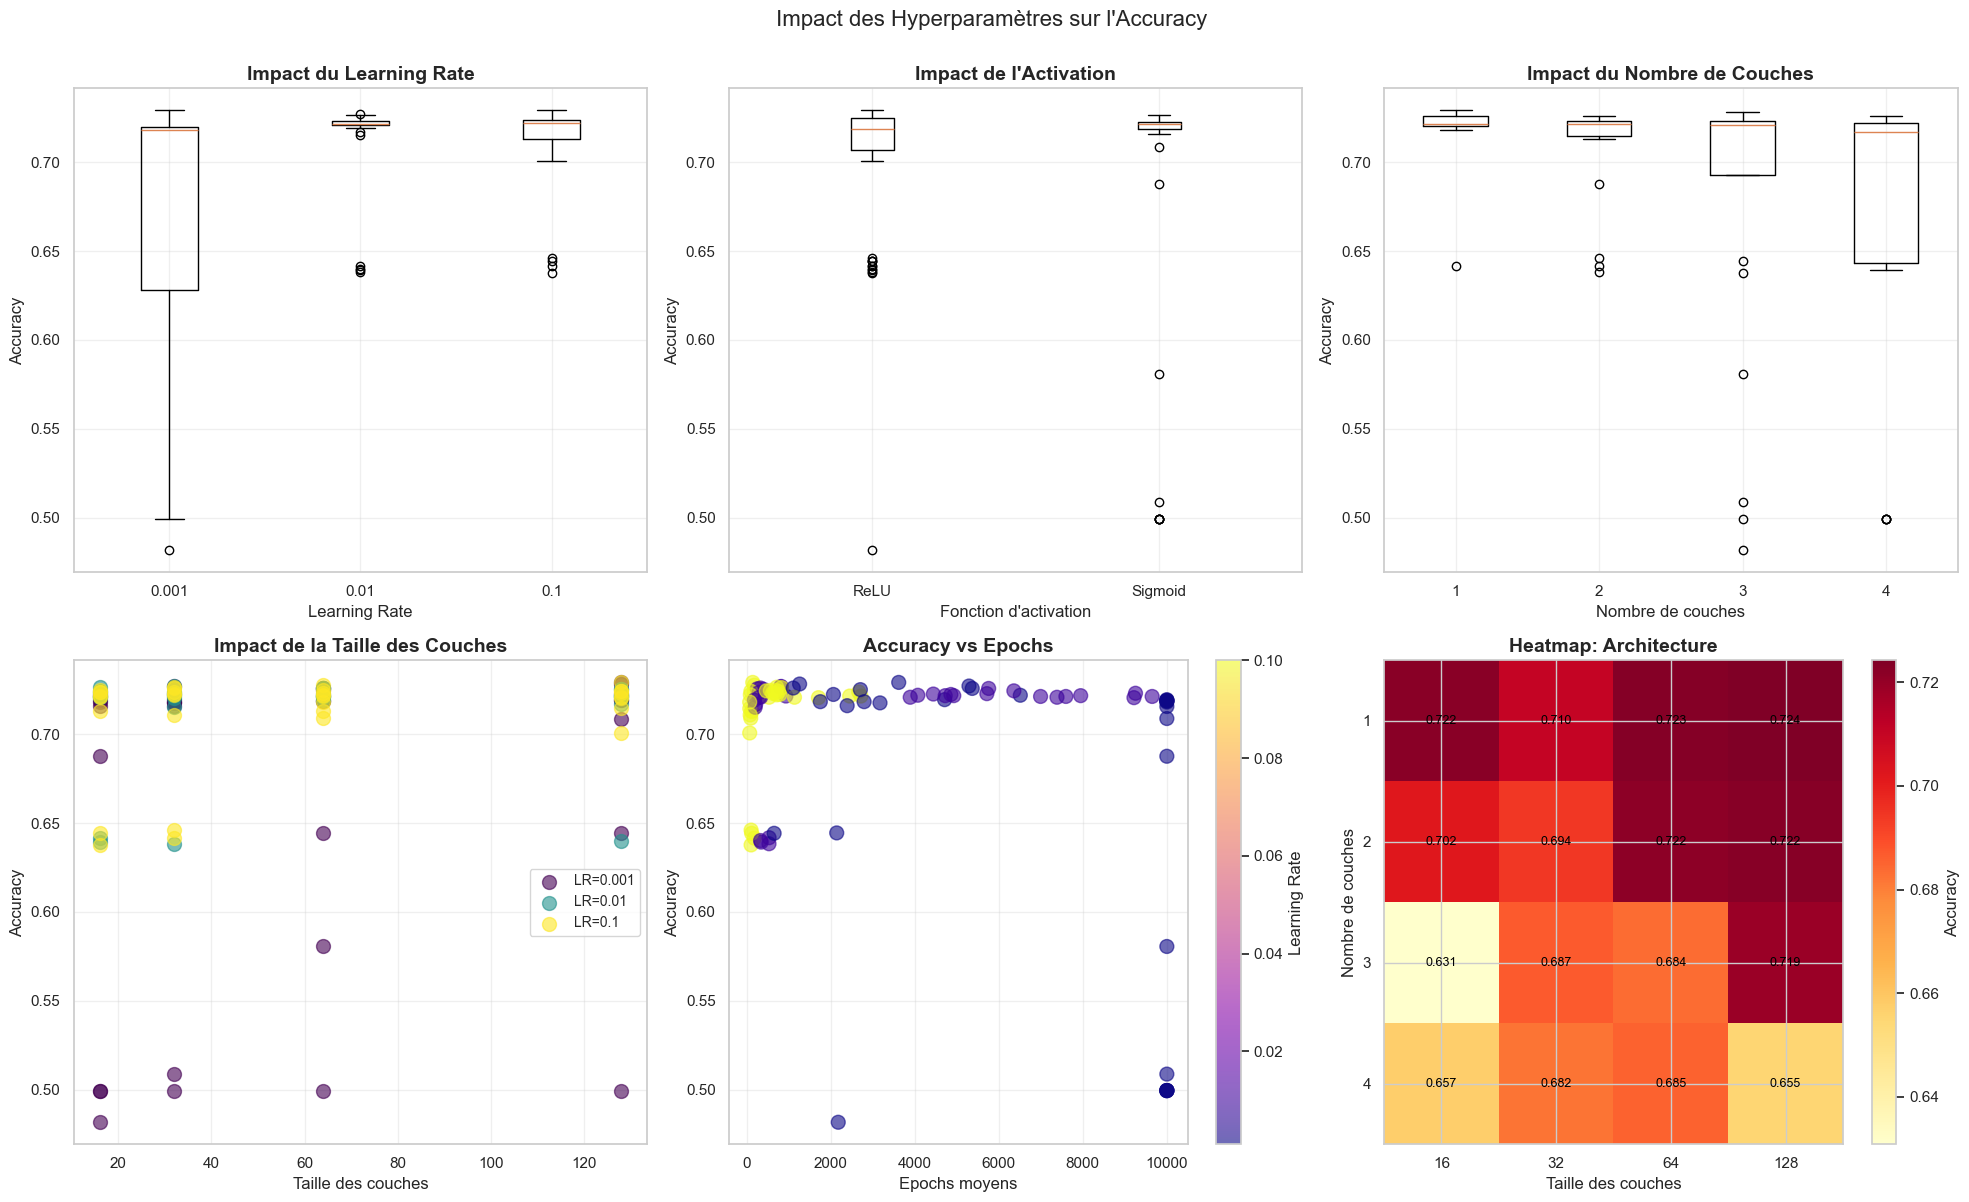

✓ Analyse terminée!
✓ 96 combinaisons testées
✓ 480 entraînements effectués


In [81]:
# ============================================
# GRID SEARCH D'HYPERPARAMÈTRES OPTIMISÉ
# ============================================

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import KFold
import time
from itertools import product
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

# Recharger les modules
import layer
import MLP
import activation_fonctions

importlib.reload(layer)
importlib.reload(MLP)
importlib.reload(activation_fonctions)

from MLP import ANN
from activation_fonctions import Activation_Fonctions

print("=" * 80)
print("GRID SEARCH D'HYPERPARAMÈTRES OPTIMISÉ")
print("=" * 80)

# ============================================
# VÉRIFICATIONS PRÉLIMINAIRES
# ============================================
required_vars = ['X_trainVal', 'y_trainVal', 'X_train', 'X_val', 'y_train', 'y_val', 'X']
missing_vars = [var for var in required_vars if var not in locals()]

if missing_vars:
    raise ValueError(f"Variables manquantes: {missing_vars}. Exécutez d'abord la cellule de préparation.")

initial_input_size = X.shape[1]

# ============================================
# DÉFINITION DE LA GRID D'HYPERPARAMÈTRES
# ============================================
print("\n1. Définition de la grid d'hyperparamètres")
print("-" * 80)

param_grid = {
    'n_layers': [1, 2, 3, 4],
    'layer_sizes': [16, 32, 64, 128],
    'learning_rate': [0.001, 0.01, 0.1],
    'activation': ['ReLU', 'Sigmoid']
}

# Paramètres fixes
fixed_batch_size = 128
max_epochs = 10000
patience = 50
min_delta = 1e-6
n_runs_per_combination = 5

# Affichage des paramètres
for key, values in param_grid.items():
    print(f" - {key}: {values}")
print(f" - Batch size (fixe): {fixed_batch_size}")
print(f" - Max epochs: {max_epochs}")
print(f" - Early stopping: patience={patience}, min_delta={min_delta}")
print(f" - Runs par combinaison: {n_runs_per_combination}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
total_runs = total_combinations * n_runs_per_combination

print(f"\nNombre total de combinaisons: {total_combinations}")
print(f"Nombre total d'entraînements: {total_runs}")

# ============================================
# OPTIMISATION MÉMOIRE
# ============================================
print("\n🔧 Optimisation mémoire...")
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)

print(f"✓ Données converties en float32")
print(f" - X_train: {X_train.shape}, {X_train.nbytes / 1e6:.2f} MB")
print(f" - X_val: {X_val.shape}, {X_val.nbytes / 1e6:.2f} MB")

# ============================================
# FONCTIONS AUXILIAIRES
# ============================================

def evaluate_model(model, X_val, y_val):
    """Évalue un modèle sur un set de validation."""
    y_pred = model.predict(X_val)
    val_loss = model.cross_entropy(y_val, y_pred)
    
    y_true_labels = np.argmax(y_val, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)
    
    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true_labels, y_pred_labels, average='weighted', zero_division=0)
    
    return {
        'loss': val_loss,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }


def train_single_run(run_idx, n_layers, layer_size, lr, activation_name, 
                     X_train, y_train, X_val, y_val, initial_input_size, 
                     optimal_batch_size, patience, min_delta):
    """Exécute un seul run d'entraînement."""
    try:
        # Initialiser les fonctions d'activation
        activation_funcs = Activation_Fonctions()
        activation_map = {
            'ReLU': activation_funcs.ReLU_activation,
            'Sigmoid': activation_funcs.sigmoid_activation
        }
        
        # Créer la structure des couches
        size_of_layers = [layer_size] * n_layers
        activation_func = activation_map[activation_name]
        
        # Créer et entraîner le modèle
        model = ANN(
            learning_rate=lr,
            size_of_layers=size_of_layers,
            initial_input_size=initial_input_size,
            activation_fonction=activation_func
        )
        
        history = model.fit(
            X_train, y_train,
            batch_size=optimal_batch_size,
            validation_data=(X_val, y_val),
            verbose=False,
            patience=patience,
            min_delta=min_delta
        )
        
        # Évaluer le modèle
        eval_results = evaluate_model(model, X_val, y_val)
        
        # Extraire les informations d'arrêt
        n_epochs = len(history.get('train_loss', []))
        stop_reason = history.get('stop_reason', 'Inconnu')
        
        # Nettoyer
        del model
        
        return (run_idx, eval_results, n_epochs, stop_reason, None)
        
    except Exception as e:
        return (run_idx, 
                {'loss': np.inf, 'accuracy': 0.0, 'f1_macro': 0.0, 'f1_weighted': 0.0},
                0, f'ERREUR: {str(e)}', str(e))


# ============================================
# GRID SEARCH PARALLÈLE
# ============================================
print("\n2. Grid Search avec parallélisation")
print("-" * 80)

results = []
start_time = time.time()

best_val_accuracy = 0.0
best_combination = None
best_combination_idx = 0

# Générer toutes les combinaisons
combinations = list(product(
    param_grid['n_layers'],
    param_grid['layer_sizes'],
    param_grid['learning_rate'],
    param_grid['activation']
))

for combination_idx, (n_layers, layer_size, lr, activation_name) in enumerate(combinations, 1):
    print(f"\n{'='*80}")
    print(f"Combinaison {combination_idx}/{total_combinations}")
    print(f" - Architecture: {n_layers} x {layer_size} neurones")
    print(f" - Learning rate: {lr}")
    print(f" - Activation: {activation_name}")
    print(f" - Batch size: {fixed_batch_size}")
    print(f"{'='*80}")
    
    # Calculer le batch size optimal
    optimal_batch_size = min(fixed_batch_size, len(X_train))
    
    # Stocker les résultats des runs
    run_results = []
    run_epochs = []
    run_stop_reasons = []
    
    # Exécuter les runs en séquence (plus stable que ThreadPoolExecutor)
    print(f"\nExécution de {n_runs_per_combination} runs...")
    for run_idx in range(n_runs_per_combination):
        result = train_single_run(
            run_idx, n_layers, layer_size, lr, activation_name,
            X_train, y_train, X_val, y_val, initial_input_size,
            optimal_batch_size, patience, min_delta
        )
        
        run_idx, eval_results, n_epochs, stop_reason, error = result
        
        run_results.append(eval_results)
        run_epochs.append(n_epochs)
        run_stop_reasons.append(stop_reason)
        
        # Affichage en temps réel
        stopped_epoch = n_epochs - 1 if n_epochs > 0 else 0
        print(f" Run {run_idx+1}/{n_runs_per_combination}: "
              f"Acc={eval_results['accuracy']:.4f}, "
              f"F1_macro={eval_results['f1_macro']:.4f}, "
              f"Loss={eval_results['loss']:.5f}, "
              f"Epochs={n_epochs} (arrêté: {stop_reason})")
    
    # Calculer les statistiques
    valid_losses = [r['loss'] for r in run_results if r['loss'] != np.inf]
    
    stats = {
        'n_layers': n_layers,
        'layer_size': layer_size,
        'learning_rate': lr,
        'activation': activation_name,
        'batch_size': fixed_batch_size,
        'avg_loss': np.mean(valid_losses) if valid_losses else np.inf,
        'std_loss': np.std(valid_losses) if valid_losses else 0,
        'avg_accuracy': np.mean([r['accuracy'] for r in run_results]),
        'std_accuracy': np.std([r['accuracy'] for r in run_results]),
        'avg_f1_macro': np.mean([r['f1_macro'] for r in run_results]),
        'std_f1_macro': np.std([r['f1_macro'] for r in run_results]),
        'avg_f1_weighted': np.mean([r['f1_weighted'] for r in run_results]),
        'std_f1_weighted': np.std([r['f1_weighted'] for r in run_results]),
        'avg_epochs': np.mean(run_epochs),
        'std_epochs': np.std(run_epochs),
        'run_results': run_results,
        'stop_reasons': run_stop_reasons,
        'run_epochs': run_epochs
    }
    
    results.append(stats)
    
    # Afficher les résultats moyens
    print(f"\n📊 Résultats moyens:")
    print(f" Accuracy: {stats['avg_accuracy']:.4f} (±{stats['std_accuracy']:.4f})")
    print(f" F1 macro: {stats['avg_f1_macro']:.4f} (±{stats['std_f1_macro']:.4f})")
    print(f" F1 weighted: {stats['avg_f1_weighted']:.4f} (±{stats['std_f1_weighted']:.4f})")
    print(f" Loss: {stats['avg_loss']:.5f} (±{stats['std_loss']:.5f})")
    print(f" Epochs: {stats['avg_epochs']:.1f} (±{stats['std_epochs']:.1f})")
    
    # Vérifier si c'est le meilleur modèle
    if stats['avg_accuracy'] > best_val_accuracy:
        best_val_accuracy = stats['avg_accuracy']
        best_combination = stats.copy()
        best_combination_idx = combination_idx
        
        print(f"\n🎯 ⭐ NOUVEAU MEILLEUR MODÈLE! ⭐")
        print(f" Accuracy: {best_val_accuracy:.4f}")

elapsed_time = time.time() - start_time
print(f"\n{'='*80}")
print(f"Grid Search terminé en {elapsed_time/60:.2f} minutes")
print(f"{'='*80}")

# ============================================
# ANALYSE DES RÉSULTATS
# ============================================
print("\n3. Analyse des résultats")
print("-" * 80)

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('avg_accuracy', ascending=False)

print("\nTop 10 meilleures combinaisons:")
display_cols = ['n_layers', 'layer_size', 'learning_rate', 'activation', 
                'avg_accuracy', 'std_accuracy', 'avg_f1_macro', 'avg_epochs']
print(results_df_sorted[display_cols].head(10).to_string(index=False))

# Afficher le meilleur modèle
print(f"\n{'='*80}")
print(f"⭐ MEILLEURE COMBINAISON ⭐")
print(f"{'='*80}")
best = best_combination if best_combination else results_df_sorted.iloc[0]
print(f" - Architecture: {int(best['n_layers'])} x {int(best['layer_size'])}")
print(f" - Learning rate: {best['learning_rate']}")
print(f" - Activation: {best['activation']}")
print(f" - Batch size: {int(best['batch_size'])}")
print(f" - Accuracy: {best['avg_accuracy']:.4f} (±{best['std_accuracy']:.4f})")
print(f" - F1 macro: {best['avg_f1_macro']:.4f} (±{best['std_f1_macro']:.4f})")
print(f" - F1 weighted: {best['avg_f1_weighted']:.4f} (±{best['std_f1_weighted']:.4f})")
print(f" - Loss: {best['avg_loss']:.5f} (±{best['std_loss']:.5f})")
print(f" - Epochs: {best['avg_epochs']:.1f} (±{best['std_epochs']:.1f})")

# ============================================
# VISUALISATIONS
# ============================================
print("\n4. Génération des visualisations...")
print("-" * 80)

# Figure 1: Impact des hyperparamètres sur l'Accuracy
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Impact des Hyperparamètres sur l\'Accuracy', fontsize=16, y=1.00)

# 1. Learning Rate
lr_data = [results_df[results_df['learning_rate'] == lr]['avg_accuracy'].values 
           for lr in sorted(results_df['learning_rate'].unique())]
bp1 = axes[0, 0].boxplot(lr_data, labels=sorted(results_df['learning_rate'].unique()))
axes[0, 0].set_xlabel('Learning Rate', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Impact du Learning Rate', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Fonction d'activation
act_data = [results_df[results_df['activation'] == act]['avg_accuracy'].values 
            for act in sorted(results_df['activation'].unique())]
bp2 = axes[0, 1].boxplot(act_data, labels=sorted(results_df['activation'].unique()))
axes[0, 1].set_xlabel('Fonction d\'activation', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Impact de l\'Activation', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Nombre de couches
layers_data = [results_df[results_df['n_layers'] == n]['avg_accuracy'].values 
               for n in sorted(results_df['n_layers'].unique())]
bp3 = axes[0, 2].boxplot(layers_data, labels=sorted(results_df['n_layers'].unique()))
axes[0, 2].set_xlabel('Nombre de couches', fontsize=12)
axes[0, 2].set_ylabel('Accuracy', fontsize=12)
axes[0, 2].set_title('Impact du Nombre de Couches', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Taille des couches (scatter)
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df['learning_rate'].unique())))
for idx, lr in enumerate(sorted(results_df['learning_rate'].unique())):
    mask = results_df['learning_rate'] == lr
    axes[1, 0].scatter(results_df[mask]['layer_size'], 
                      results_df[mask]['avg_accuracy'],
                      label=f'LR={lr}', alpha=0.6, s=100, c=[colors[idx]])
axes[1, 0].set_xlabel('Taille des couches', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].set_title('Impact de la Taille des Couches', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 5. Epochs vs Accuracy
scatter = axes[1, 1].scatter(results_df['avg_epochs'], 
                            results_df['avg_accuracy'],
                            c=results_df['learning_rate'], 
                            cmap='plasma', alpha=0.6, s=100)
axes[1, 1].set_xlabel('Epochs moyens', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].set_title('Accuracy vs Epochs', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Learning Rate')

# 6. Heatmap Architecture
pivot_table = results_df.pivot_table(
    values='avg_accuracy',
    index='n_layers',
    columns='layer_size',
    aggfunc='mean'
)
im = axes[1, 2].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1, 2].set_xticks(range(len(pivot_table.columns)))
axes[1, 2].set_xticklabels(pivot_table.columns)
axes[1, 2].set_yticks(range(len(pivot_table.index)))
axes[1, 2].set_yticklabels(pivot_table.index)
axes[1, 2].set_xlabel('Taille des couches', fontsize=12)
axes[1, 2].set_ylabel('Nombre de couches', fontsize=12)
axes[1, 2].set_title('Heatmap: Architecture', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1, 2], label='Accuracy')

# Ajouter les valeurs dans la heatmap
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        text = axes[1, 2].text(j, i, f'{pivot_table.values[i, j]:.3f}',
                              ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Analyse terminée!")
print(f"✓ {len(results)} combinaisons testées")
print(f"✓ {total_runs} entraînements effectués")

In [82]:
# ============================================
# ENTRAÎNEMENT DU MEILLEUR MODÈLE SUR TOUTES LES DONNÉES
# ============================================

from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

print("=" * 80)
print("ENTRAÎNEMENT DU MEILLEUR MODÈLE")
print("=" * 80)

# Vérifier que best_result existe
if 'best_result' not in locals():
    # Vérifier si results_df existe (indique que la grid search a été exécutée)
    if 'results_df' in locals() or 'results_df_sorted' in locals():
        raise ValueError(
            "best_result n'existe pas mais results_df est présent.\n"
            "La grid search a été exécutée mais best_result n'a pas été créé.\n"
            "Vérifiez la cellule de grid search qui crée best_result (généralement après la création de results_df)."
        )
    else:
        raise ValueError(
            "best_result n'existe pas. Vous devez d'abord exécuter la cellule de grid search.\n"
            "Cherchez la cellule qui contient 'GRID SEARCH D'HYPERPARAMÈTRES' et exécutez-la complètement."
        )

# Vérifier que les données sont disponibles
if 'X_train' not in locals() or 'y_train' not in locals() or 'X_test' not in locals() or 'y_test' not in locals():
    raise ValueError("Les données train/test doivent être préparées. Exécutez d'abord la cellule 18.")

print("\n1. Création du meilleur modèle")
print("-" * 80)

# Extraire les hyperparamètres de la meilleure combinaison
best_n_layers = int(best_result['n_layers'])
best_layer_size = int(best_result['layer_size'])
best_lr = best_result['learning_rate']
best_activation_name = best_result['activation']
best_batch_size = int(best_result['batch_size'])

# Créer la structure des couches
best_size_of_layers = [best_layer_size] * best_n_layers

# Sélectionner la fonction d'activation
activation_funcs = Activation_Fonctions()
activation_map = {
    'ReLU': activation_funcs.ReLU_activation,
    'Sigmoid': activation_funcs.sigmoid_activation
}
best_activation_func = activation_map[best_activation_name]

print(f"Hyperparamètres du meilleur modèle:")
print(f"  - Nombre de couches: {best_n_layers}")
print(f"  - Taille des couches: {best_layer_size}")
print(f"  - Learning rate: {best_lr}")
print(f"  - Activation: {best_activation_name}")
print(f"  - Batch size: {best_batch_size}")

# Créer le modèle
best_model = ANN(
    learning_rate=best_lr,
    size_of_layers=best_size_of_layers,
    initial_input_size=initial_input_size,
    activation_fonction=best_activation_func
)

print(f"\n✓ Modèle créé avec succès")
print(f"  Architecture: {initial_input_size} -> {' -> '.join(map(str, best_size_of_layers))} -> 3")

# ============================================
# ENTRAÎNEMENT SUR TOUTES LES DONNÉES D'ENTRAÎNEMENT
# ============================================
print("\n2. Entraînement sur toutes les données d'entraînement")
print("-" * 80)

# Combiner train et validation pour l'entraînement final
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.vstack([y_train, y_val])

print(f"Données d'entraînement: {X_train_final.shape[0]} échantillons")
print(f"Données de test: {X_test.shape[0]} échantillons")

# Entraîner le modèle avec batching
print(f"\nDémarrage de l'entraînement avec batch_size={best_batch_size}...")
print(f"Early stopping avec patience=50 et min_delta=1e-6")
start_time = time.time()

history = best_model.fit(
    X_train_final,
    y_train_final,
    batch_size=best_batch_size,
    validation_data=(X_test, y_test),
    verbose=True,
    patience=50,
    min_delta=1e-6
)

elapsed_time = time.time() - start_time
print(f"\n✓ Entraînement terminé en {elapsed_time/60:.2f} minutes ({elapsed_time:.2f} secondes)")

# ============================================
# ÉVALUATION SUR LE SET DE TEST
# ============================================
print("\n3. Évaluation sur le set de test")
print("-" * 80)

# Prédictions
y_test_pred = best_model.predict(X_test)
y_test_pred_labels = np.argmax(y_test_pred, axis=1)
y_test_true_labels = np.argmax(y_test, axis=1)

# Métriques
test_loss = best_model.cross_entropy(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test_true_labels, y_test_pred_labels)
test_f1_macro = f1_score(y_test_true_labels, y_test_pred_labels, average='macro')
test_f1_weighted = f1_score(y_test_true_labels, y_test_pred_labels, average='weighted')

print(f"Résultats sur le set de test:")
print(f"  - Loss: {test_loss:.5f}")
print(f"  - Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - F1 Score (macro): {test_f1_macro:.4f}")
print(f"  - F1 Score (weighted): {test_f1_weighted:.4f}")
print(f"  - Epochs d'entraînement: {len(history['train_loss'])}")

# Rapport de classification détaillé
print(f"\nRapport de classification:")
print(classification_report(
    y_test_true_labels,
    y_test_pred_labels,
    target_names=classNames
))

# Matrice de confusion
cm = confusion_matrix(y_test_true_labels, y_test_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classNames, yticklabels=classNames)
plt.xlabel('Prédictions')
plt.ylabel('Vraies classes')
plt.title('Matrice de confusion - Set de test')
plt.tight_layout()
plt.show()

# Distribution des prédictions
print(f"\nDistribution des prédictions:")
pred_counts = pd.Series(y_test_pred_labels).value_counts().sort_index()
for i, className in enumerate(classNames):
    count = pred_counts.get(i, 0)
    pct = count / len(y_test_pred_labels) * 100
    print(f"  - {className}: {count} ({pct:.1f}%)")

print(f"\n{'='*80}")
print("ENTRAÎNEMENT ET ÉVALUATION TERMINÉS")
print(f"{'='*80}")
print(f"✓ Meilleur modèle sauvegardé dans 'best_model'")
print(f"✓ Accuracy finale sur test: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


ENTRAÎNEMENT DU MEILLEUR MODÈLE


ValueError: best_result n'existe pas mais results_df est présent.
La grid search a été exécutée mais best_result n'a pas été créé.
Vérifiez la cellule de grid search qui crée best_result (généralement après la création de results_df).